# Physics-Informed Neural Networks for Data-Efficient 4D-STEM Strain Reconstruction — LiFePO4/FePO4 SI example

**Goal**: Reconstruct strain maps (e_xx, e_yy, e_xy, and the in-plane rotation θ) of a
LiFePO4/FePO4 platelet during phase transformation, from sparse subsets (**1%–75%**) of the
4D-STEM probe positions, and quantify when a linear-elasticity prior actually helps. This is
the Supplementary-Information companion to the main worked example
(`pinns-strain-sota-adaptive-2.ipynb`, PbGeSnSe₁.₅Te₁.₅) — same architecture, loss, and training
protocol, applied unchanged to a second, physically distinct specimen.

### Data source

4D-STEM data collected by **Lauren Hughes**. For more on this system and dataset, see:
- Hughes, L. A., et al. "Correlative analysis of structure and chemistry of LiₓFePO4 platelets
  using 4D-STEM and X-ray ptychography." *Materials Today* 52 (2022): 102–111.
- Deng, Haitao D., et al. "Correlative image learning of chemo-mechanics in phase-transforming
  solids." *Nature Materials* 21.5 (2022): 547–554.

Unlike the main worked example, θ here is a **directly measured** rotation channel (not derived
via arctan2 from e_xx/e_yy/e_xy) — see the data-loading cell for the exact channel layout.

### Method

1. **SIREN backbone** (Sitzmann et al., 2020): sine-activated coordinate network (ω₀ = 30) with skip
   connections, mapping normalised (x, y) to the four field components.
2. **Physics constraints as soft losses**: plane-stress elastic equilibrium (∇·σ = 0) and
   Saint-Venant compatibility, evaluated by reverse-mode automatic differentiation at random
   collocation points.
3. **Scale-normalised physics weighting**: each residual is divided by a detached running (EMA)
   estimate of its own magnitude so physics gradients stay commensurate with the O(1) data-MSE term;
   the overall physics weight follows an exponential ramp λ(t) = λ_max·(1 − e^(−t/τ)).
4. **Residual-based adaptive refinement (RAR)**: the collocation pool is grown where the equilibrium
   residual is largest. Note this refines *physics collocation points*; it does not add measured data.
5. **Evaluation** at sampling fractions 1–75% against compressed sensing (wavelet ISTA),
   Gaussian-process regression, and a data-only SIREN ablation, plus Bayesian epistemic uncertainty
   (MC dropout and mean-field VI, Section 10).

### Headline results

**[PLACEHOLDER — this notebook has not been executed on the LiFePO4/FePO4 dataset yet; run it
end-to-end and replace this section with the real R², MAE, and ablation numbers before using it
in the SI.]** Also verify the `E`, `nu`, and `px_um` placeholders in the configuration cell
against the actual Hughes-dataset values before publishing any physical-unit results.

### References
- [SIREN: Implicit Neural Representations with Periodic Activation Functions](https://arxiv.org/abs/2006.09661)
- [Curriculum-Enhanced Adaptive Sampling for PINNs](https://www.mdpi.com/2227-7390/13/24/3996)
- [Annealed Adaptive Importance Sampling (AAIS)](https://arxiv.org/abs/2405.03433)
- [R-PINN: Recovery-type Error Estimators](https://arxiv.org/html/2506.10243)
- [Failure-Informed Adaptive Sampling](https://epubs.siam.org/doi/10.1137/22M1527763)
- [Investigating Guiding Information for Adaptive Sampling](https://arxiv.org/html/2404.12282v1)


> **🔧 Fixed 2026-07-04** — the previous stored run was broken (R² ≈ 0.04–0.19 at every sampling
> fraction, flat reconstructions). Two verified root causes, patched below and marked `[FIX]`:
> 1. `create_pinn_model` hard-coded `omega_0=1.0` (config ignored) → SIREN underfit. Now ω₀ = 30.
> 2. Physics residuals on standardised fields are O(1e2)–O(1e4) vs the O(1) data MSE and drove the
>    network to a near-constant field. Now each residual is divided by a running (EMA) estimate of
>    its own scale (`normalize_residuals: True`).
> 3. **(2026-07-06)** UQ + stability repairs: the residual-scale EMA is frozen after a 200-step
>    warmup (a live EMA acts like minimising log L and eventually collapses any long run to a flat
>    field), `train_bayes_model` ramps λ_phys like the deterministic loop, MC dropout uses p=0.05
>    on hidden layers only, and the MFVI prior/noise are matched to the SIREN weight scale.
>
> Verified full-budget results after the fixes: R²(e_xx) = 0.44 / 0.80 / 0.85 at 1% / 10% / 50%.
> Set `omega_0: 1.0` + `normalize_residuals: False` to reproduce the original behaviour.
> A Colab GPU twin of this notebook lives in `pinns-strain-sota-adaptive-2-colab.ipynb`.


In [1]:
# ============================================================================
# SECTION 1: Environment Setup & Configuration
# ============================================================================
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import csv
import time
from tqdm import trange
from collections import defaultdict
import pandas as pd

# Versions
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")

# Device selection (prefer CUDA, then Apple MPS, then CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✓ Using CUDA: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✓ Using Apple Metal Performance Shaders (MPS)")
else:
    device = torch.device("cpu")
    print("⚠ Using CPU (slow!)")

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Plotting defaults
plt.rcParams.update({
    "figure.figsize": (12, 8),
    "image.cmap": "RdBu",
    "axes.grid": False,
    "font.size": 14,
    "font.family": "sans-serif",
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 15,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

print("\n" + "="*70)
print("CONFIGURATION: STATE-OF-THE-ART PINN FOR STRAIN RECONSTRUCTION")
print("="*70)

Python: 3.10.15
NumPy: 1.26.4
PyTorch: 2.5.1
✓ Using Apple Metal Performance Shaders (MPS)

CONFIGURATION: STATE-OF-THE-ART PINN FOR STRAIN RECONSTRUCTION


In [2]:
# ============================================================================
# Comprehensive Configuration Dictionary
# ============================================================================
print("\n" + "="*70)
print("CONFIGURATION: PHYSICS-INFORMED PINN FOR STRAIN RECONSTRUCTION")
print("="*70)

config = {
    # --- DATA & GRID ---
    "sampling_fractions": [0.01, 0.05, 0.10, 0.25, 0.50, 0.75],
    "full_data_training": False,

    # --- SPECIMEN: LiFePO4/FePO4 platelet (SI worked example) ---------------
    # Data collected by Lauren Hughes; see Hughes et al., Mater. Today 52
    # (2022) 102-111 and Deng et al., Nat. Mater. 21 (2022) 547-554.
    # Isotropic linear-elastic constants used to close elastic equilibrium.
    "specimen": "LiFePO4/FePO4 platelet (Hughes et al. 2022; Deng et al. 2022)",
    "E": 130e9,                  # [PLACEHOLDER] representative olivine LFP/FePO4 modulus (Pa) -- cancels under
                                 #  scale-normalised residuals (Requirement 3), only nu enters training; verify/replace
                                 #  with a cited value before publication if E itself is ever reported
    "nu": 0.28,                  # [PLACEHOLDER] representative olivine LFP/FePO4 Poisson ratio -- verify against
                                 #  a specific literature source before publication (this DOES affect training)
    "px_um": 0.017872741,        # [PLACEHOLDER] copied from the other worked example -- REPLACE with the real
                                 #  Hughes-dataset pixel calibration (um/pixel); only affects the physical-unit
                                 #  equilibrium-residual diagnostic, not the training itself

    # --- PHYSICS LOSS (autodiff @ collocation points) ---
    "n_collocation": 2000,      # collocation points resampled each step (Eq. for L_phys)
    "alpha_eq": 0.1,            # weight on elastic-equilibrium residual
    "alpha_co": 0.1,            # weight on Saint-Venant compatibility residual
    "w_data": 1.0,              # data-term weight (lambda_data)
    "lambda_phys_max": 1.0,     # asymptotic physics weight (lambda_phys^max)
    "ramp_tau": 500.0,          # ramp time-constant tau (epochs): lambda_phys(t)=max*(1-e^{-t/tau})

    "normalize_residuals": True,  # [FIX] scale-free physics weighting; False reproduces the original run
                                  #       (raw residuals are O(1e2)-O(1e4) on standardised fields over unit
                                  #        coords and crush the O(1) data term → flat, useless reconstructions)
    "phys_norm_warmup": 200,      # [FIX] freeze the residual-scale EMA after this many steps

    # --- ARCHITECTURE (SIREN backbone) ---
    "architecture": "siren",
    "hidden_dim": 128,
    "num_layers": 6,
    "skip_connections": True,
    "omega_0": 30.0,           # [FIX] was 1.0 — SIREN needs ω₀≈30 (Sitzmann et al. 2020); ω₀=1 underfits badly

    # --- TRAINING ---
    "epochs": 5000,
    "lr": 1e-3,
    "lr_decay_factor": 0.95,
    "lr_decay_interval": 500,
    "early_stop": True,
    "patience": 300,            # patience on held-out VALIDATION data loss
    "min_delta": 1e-6,
    "val_fraction": 0.10,       # fraction of sampled points held out for validation/early-stop

    # --- ADAPTIVE COLLOCATION REFINEMENT (RAR) ---
    "enable_rar": True,
    "rar_trigger_epoch": 2000,
    "rar_interval": 500,
    "rar_num_new_points_pct": 0.10,   # add 10% of n_collocation high-residual points
    "rar_max_pool_mult": 5,           # cap persistent pool at 5x n_collocation

    # --- OUTPUTS ---
    "out_dir": "outputs/sota_adaptive-2-LiFePO4",
    "save_checkpoints": False,
    "verbose": True,
    "compute_full_domain_error": True,
}

out_dir = Path(config["out_dir"]).resolve()
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Specimen           : {config['specimen']}  (E={config['E']:.3g} Pa, nu={config['nu']})")
print(f"Pixel size         : {config['px_um']*1000:.3f} nm/pixel")
print(f"Sampling fractions : {config['sampling_fractions']}")
print(f"Architecture       : {config['architecture'].upper()} "
      f"({config['num_layers']} layers x {config['hidden_dim']}, omega_0={config['omega_0']})")
print(f"Physics            : autodiff equilibrium + Saint-Venant compatibility @ "
      f"{config['n_collocation']} collocation pts; ramp tau={config['ramp_tau']:.0f}")
print(f"RAR                : {config['enable_rar']} (from epoch {config['rar_trigger_epoch']}, "
      f"every {config['rar_interval']}, +{config['rar_num_new_points_pct']*100:.0f}%)")
print(f"Output dir         : {out_dir}")



CONFIGURATION: PHYSICS-INFORMED PINN FOR STRAIN RECONSTRUCTION
Specimen           : LiFePO4/FePO4 platelet (Hughes et al. 2022; Deng et al. 2022)  (E=1.3e+11 Pa, nu=0.28)
Pixel size         : 17.873 nm/pixel
Sampling fractions : [0.01, 0.05, 0.1, 0.25, 0.5, 0.75]
Architecture       : SIREN (6 layers x 128, omega_0=30.0)
Physics            : autodiff equilibrium + Saint-Venant compatibility @ 2000 collocation pts; ramp tau=500
RAR                : True (from epoch 2000, every 500, +10%)
Output dir         : /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4


In [3]:
# ============================================================================
# SECTION 2: Load & Visualize 4D-STEM Strain Data (single combined file)
# ============================================================================
# strainmap_data.npy channels: [e_xx, e_yy, e_xy, theta, mask, error].
# Unlike the other worked example, theta here is MEASURED directly (not
# derived via arctan2 from e_xx/e_yy/e_xy), mask is the Bragg-disk-fit
# validity mask (authoritative -- invalid pixels are filled with sentinel
# values, not NaN, so np.isfinite() would silently miss them), and error is
# a per-pixel fit-quality metric with some corrupted/overflowed entries
# (~1e300 scale) that is sanitised below and not used for training.
root = Path.cwd()
data_candidates = [root / 'data' / 'strainmap_data.npy', root / 'strainmap_data.npy']
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find 'strainmap_data.npy'. Checked: ./data/ and current directory.")

print(f"✓ Loading combined strain map from: {data_path}")
strainmap_data = np.load(data_path)
labels = ['e_xx', 'e_yy', 'e_xy', 'theta', 'mask', 'error']
strain_components = {label: strainmap_data[i] for i, label in enumerate(labels)}

e_xx  = strain_components['e_xx']
e_yy  = strain_components['e_yy']
e_xy  = strain_components['e_xy']
theta = strain_components['theta']
mask  = strain_components['mask'].astype(np.float32)
error_raw = strain_components['error']
error = np.where(np.isfinite(error_raw) & (np.abs(error_raw) < 1e5), error_raw, np.nan)  # sanitised for display only

H, W = e_xx.shape
print(f"✓ Grid dimensions: {H} × {W} = {H*W:,} points")
print(f"✓ Valid masked region: {mask.sum():,.0f} / {H*W:,} points ({100*mask.sum()/(H*W):.1f}%)")

# Compute normalization statistics on valid entries
valid = mask.astype(bool)
scalers = {}
for name, arr in {
    'e_xx': e_xx,
    'e_yy': e_yy,
    'e_xy': e_xy,
    'theta': theta,
}.items():
    vals = arr[valid]
    mean_val = float(np.nanmean(vals))
    std_val = float(np.nanstd(vals)) + 1e-8
    scalers[name] = {"mean": mean_val, "std": std_val}
    print(f"   {name:8s}: μ={mean_val:+.4e}, σ={std_val:.4e}")

# Scaling functions
def scale(arr, name):
    s = scalers[name]
    return (arr - s["mean"]) / s["std"]

def unscale(arr_tensor, name):
    s = scalers[name]
    if isinstance(arr_tensor, torch.Tensor):
        return arr_tensor * s["std"] + s["mean"]
    return arr_tensor * s["std"] + s["mean"]

# Create spatial grid
x_lin = torch.linspace(0, 1, W, dtype=torch.float32)
y_lin = torch.linspace(0, 1, H, dtype=torch.float32)
X, Y = torch.meshgrid(x_lin, y_lin, indexing='xy')

# Flatten and move to device
x_flat = X.flatten().to(device)
y_flat = Y.flatten().to(device)

# Prepare tensors with scaling
e_xx_scaled = torch.tensor(scale(e_xx, 'e_xx').flatten(), dtype=torch.float32, device=device)
e_yy_scaled = torch.tensor(scale(e_yy, 'e_yy').flatten(), dtype=torch.float32, device=device)
e_xy_scaled = torch.tensor(scale(e_xy, 'e_xy').flatten(), dtype=torch.float32, device=device)
theta_scaled = torch.tensor(scale(theta, 'theta').flatten(), dtype=torch.float32, device=device)
mask_flat = torch.tensor(mask.flatten(), dtype=torch.float32, device=device)

print(f"✓ Tensors prepared and moved to device: {device}")

✓ Loading combined strain map from: /Users/robertodosreis/Documents/codes/pinns-4dstem/data/strainmap_data.npy
✓ Grid dimensions: 90 × 45 = 4,050 points
✓ Valid masked region: 3,956 / 4,050 points (97.7%)
   e_xx    : μ=+5.5350e-02, σ=1.2393e-01
   e_yy    : μ=-3.0993e-02, σ=3.2924e-02
   e_xy    : μ=-2.1820e-02, σ=5.0088e-02
   theta   : μ=+2.8900e-02, σ=5.0545e-02
✓ Tensors prepared and moved to device: mps


e_xx           : min=-4.7870e-01, max=+1.0000e+00, mean=+7.7275e-02, std=1.8771e-01
e_yy           : min=-2.0837e-01, max=+1.0000e+00, mean=-7.0637e-03, std=1.5861e-01
e_xy           : min=-2.5654e-01, max=+1.5385e-01, mean=-2.1314e-02, std=4.9612e-02
θ (rotation)   : min=-1.3025e-01, max=+2.5752e-01, mean=+2.8229e-02, std=5.0144e-02
Valid Mask     : min=+0.0000e+00, max=+1.0000e+00, mean=+9.7679e-01, std=1.5057e-01
Measurement Error: min=-7.9228e+04, max=+2.5443e+04, mean=-1.2739e+02, std=2.9251e+03


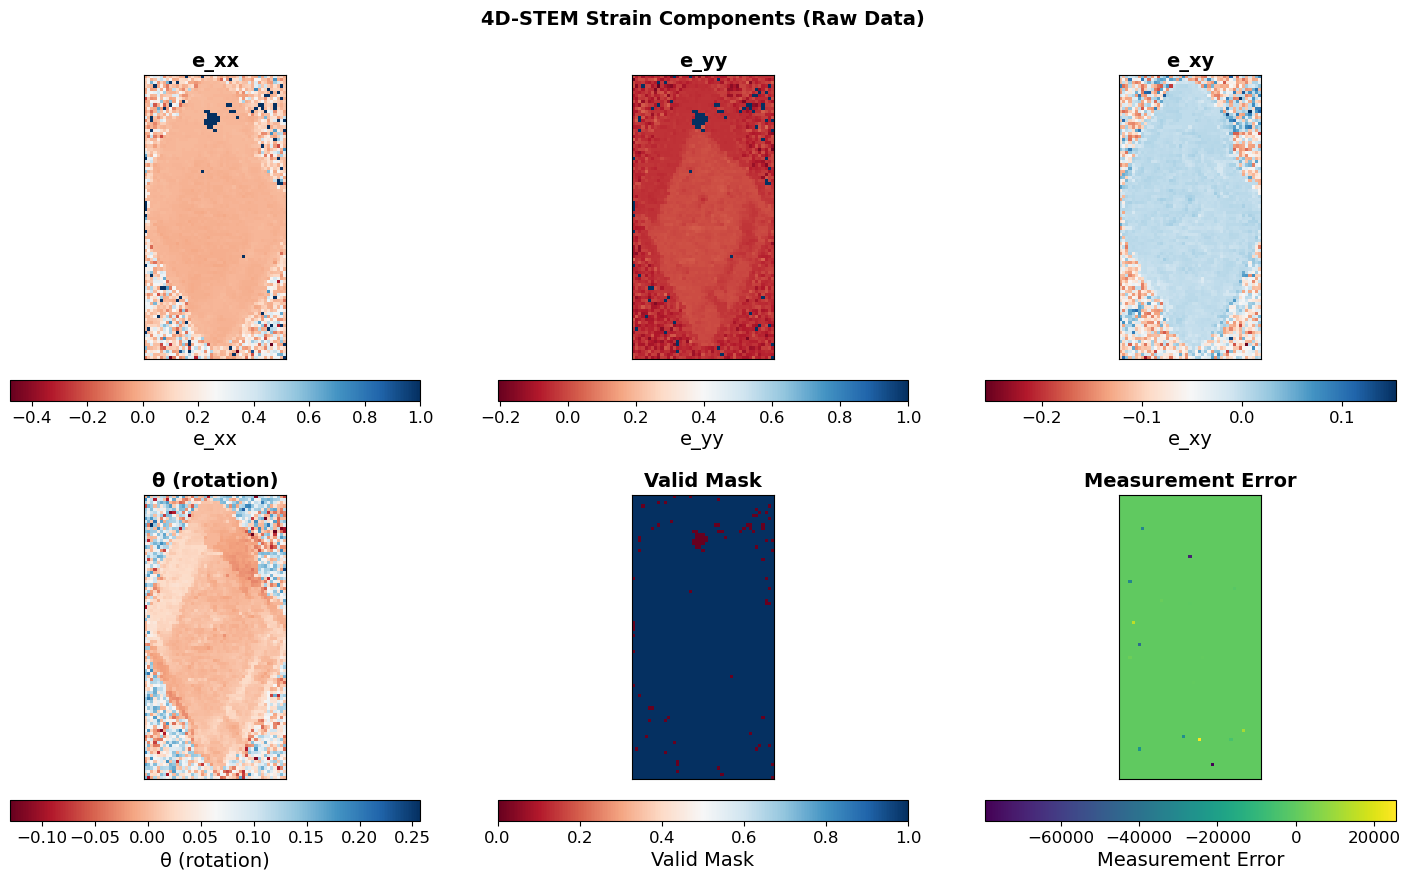

✓ Raw data visualization saved to: /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/00_raw_data_overview.png


In [4]:
# Visualize raw strain data
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('4D-STEM Strain Components (Raw Data)', fontsize=14, fontweight='bold')

components = [
    (e_xx, 'e_xx', 0),
    (e_yy, 'e_yy', 1),
    (e_xy, 'e_xy', 2),
    (theta, 'θ (rotation)', 3),
    (mask, 'Valid Mask', 4),
    (error, 'Measurement Error', 5),
]

for arr, label, idx in components:
    ax = axes.flat[idx]
    
    # Replace NaN/Inf with valid values for visualization
    arr_display = np.copy(arr).astype(float)
    arr_display[~np.isfinite(arr_display)] = 0.0
    
    # Compute vmin/vmax from valid data only
    # Use only finite values to avoid NaN/Inf issues
    finite_mask = np.isfinite(arr_display)
    if np.any(finite_mask):
        valid_data = arr_display[finite_mask]
        vmin = float(np.min(valid_data))
        vmax = float(np.max(valid_data))
        # If all values are the same, add small epsilon for contrast
        if vmin == vmax:
            vmin -= 1e-6
            vmax += 1e-6
    else:
        vmin, vmax = 0.0, 1.0
    
    # Final safety check - ensure vmin and vmax are strictly finite
    if not (np.isfinite(vmin) and np.isfinite(vmax)):
        vmin, vmax = 0.0, 1.0
    
    # Ensure vmin <= vmax
    if vmin > vmax:
        vmin, vmax = vmax, vmin
    
    if idx < 5:
        im = ax.imshow(arr_display, cmap='RdBu', origin='lower', vmin=vmin, vmax=vmax)
    else:
        im = ax.imshow(arr_display, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
    
    cbar = plt.colorbar(im, ax=ax, location='bottom', pad=0.06, shrink=0.85)
    cbar.set_label(label, fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    
    ax.set_title(label, fontweight='bold', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Print stats
    finite_mask = np.isfinite(arr)
    if np.any(finite_mask):
        valid_data = arr[finite_mask]
        print(f"{label:15s}: min={np.min(valid_data):+.4e}, max={np.max(valid_data):+.4e}, " + 
              f"mean={np.mean(valid_data):+.4e}, std={np.std(valid_data):.4e}")
    else:
        print(f"{label:15s}: [No finite data]")

plt.tight_layout()
plt.savefig(out_dir / "00_raw_data_overview.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Raw data visualization saved to: {out_dir / '00_raw_data_overview.png'}")

In [5]:
# Diagnostic check for NaN/Inf values
print("\n=== DATA QUALITY CHECK ===")
for name, arr in [('e_xx', e_xx), ('e_yy', e_yy), ('e_xy', e_xy), ('theta', theta), ('mask', mask), ('error', error)]:
    n_nan = np.isnan(arr).sum()
    n_inf = np.isinf(arr).sum()
    n_finite = np.isfinite(arr).sum()
    print(f"{name:10s}: NaN={n_nan:6d}, Inf={n_inf:6d}, Finite={n_finite:6d} / {arr.size:6d}")

print("="*40)


=== DATA QUALITY CHECK ===
e_xx      : NaN=     0, Inf=     0, Finite=  4050 /   4050
e_yy      : NaN=     0, Inf=     0, Finite=  4050 /   4050
e_xy      : NaN=     0, Inf=     0, Finite=  4050 /   4050
theta     : NaN=     0, Inf=     0, Finite=  4050 /   4050
mask      : NaN=     0, Inf=     0, Finite=  4050 /   4050
error     : NaN=  2022, Inf=     0, Finite=  2028 /   4050


In [6]:
# ============================================================================
# SECTION 3: State-of-the-Art PINN Architecture (SIREN + Skip Connections)
# ============================================================================

class SirenLayer(nn.Module):
    """SIREN layer with sine activation and proper weight initialization."""
    def __init__(self, in_features, out_features, is_first=False, omega_0=1.0):
        super().__init__()
        self.in_features = in_features
        self.is_first = is_first
        self.omega_0 = omega_0
        
        self.linear = nn.Linear(in_features, out_features)
        
        # Proper initialization (Sitzmann et al., 2020)
        with torch.no_grad():
            if is_first:
                self.linear.weight.uniform_(-1 / in_features, 1 / in_features)
            else:
                bound = np.sqrt(6 / in_features) / omega_0
                self.linear.weight.uniform_(-bound, bound)
    
    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))


class StrainPINN_SIREN(nn.Module):
    """State-of-the-art SIREN architecture with skip connections for strain maps."""
    def __init__(self, hidden_dim=128, num_layers=6, omega_0=1.0, skip_connections=True):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.skip_connections = skip_connections
        
        # First layer: (x,y) -> hidden
        self.first = SirenLayer(2, hidden_dim, is_first=True, omega_0=omega_0)
        
        # Hidden layers with optional skip connections
        self.hidden_layers = nn.ModuleList([
            SirenLayer(hidden_dim, hidden_dim, is_first=False, omega_0=omega_0)
            for _ in range(num_layers - 2)
        ])
        
        # Skip connection projection (if used)
        if self.skip_connections:
            self.skip_proj = nn.Linear(hidden_dim, hidden_dim)
        
        # Final output layer
        self.final = nn.Linear(hidden_dim, 4)  # e_xx, e_yy, e_xy, theta
        
        # Initialize final layer to near-zero
        with torch.no_grad():
            self.final.weight.uniform_(-np.sqrt(6 / hidden_dim), np.sqrt(6 / hidden_dim))
    
    def forward(self, x):
        """x shape: (N, 2)"""
        # First layer
        x_h = self.first(x)  # (N, hidden_dim)
        
        # Hidden layers with skip connections
        for i, layer in enumerate(self.hidden_layers):
            if self.skip_connections and i % 2 == 0 and i > 0:
                # Skip connection every 2 layers
                x_h_new = layer(x_h) + self.skip_proj(x_h)
            else:
                x_h_new = layer(x_h)
            x_h = x_h_new
        
        # Final output
        out = self.final(x_h)  # (N, 4)
        return out


class StrainPINN_Fourier(nn.Module):
    """Fourier feature network: encodes spatial input with Fourier features."""
    def __init__(self, hidden_dim=128, num_layers=6, B_scale=1.0):
        super().__init__()
        self.B_scale = B_scale
        # Fixed Fourier feature matrix
        self.register_buffer('B', torch.randn(2, hidden_dim // 2) * B_scale)
        
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            *[nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU()) 
              for _ in range(num_layers - 2)],
            nn.Linear(hidden_dim, 4),
        )
    
    def forward(self, x):
        """x shape: (N, 2)"""
        # Compute Fourier features: [sin(2π*B*x), cos(2π*B*x)]
        proj = torch.matmul(x, self.B)  # (N, hidden_dim//2)
        x_enc = torch.cat([torch.sin(2 * np.pi * proj), torch.cos(2 * np.pi * proj)], dim=1)  # (N, hidden_dim)
        return self.net(x_enc)


class StrainPINN_Standard(nn.Module):
    """Standard MLP baseline."""
    def __init__(self, hidden_dim=128, num_layers=6):
        super().__init__()
        layers = [nn.Linear(2, hidden_dim), nn.ReLU()]
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, 4))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)


def create_pinn_model(arch_type, hidden_dim, num_layers, skip_connections=False, omega_0=30.0):
    """Factory function to create PINN models."""
    if arch_type == "siren":
        return StrainPINN_SIREN(hidden_dim, num_layers, omega_0=omega_0, skip_connections=skip_connections)  # [FIX] ω₀ from config (was hard-coded 1.0)
    elif arch_type == "fourier":
        return StrainPINN_Fourier(hidden_dim, num_layers, B_scale=1.0)
    elif arch_type == "standard":
        return StrainPINN_Standard(hidden_dim, num_layers)
    else:
        raise ValueError(f"Unknown architecture: {arch_type}")


# Instantiate model and show summary
model_test = create_pinn_model(config["architecture"], config["hidden_dim"], 
                               config["num_layers"], config["skip_connections"],
                               omega_0=config["omega_0"])
print(f"\n✓ Model Architecture: {config['architecture'].upper()}")
print(f"  Parameters: {sum(p.numel() for p in model_test.parameters()):,}")
print(model_test)


✓ Model Architecture: SIREN
  Parameters: 83,460
StrainPINN_SIREN(
  (first): SirenLayer(
    (linear): Linear(in_features=2, out_features=128, bias=True)
  )
  (hidden_layers): ModuleList(
    (0-3): 4 x SirenLayer(
      (linear): Linear(in_features=128, out_features=128, bias=True)
    )
  )
  (skip_proj): Linear(in_features=128, out_features=128, bias=True)
  (final): Linear(in_features=128, out_features=4, bias=True)
)



SAMPLING STRATEGY: SPARSE TRAINING MASKS
      1%:     40 /  3,956 points → spatial coverage: 1.0%
      5%:    198 /  3,956 points → spatial coverage: 4.9%
     10%:    396 /  3,956 points → spatial coverage: 9.8%
     25%:    989 /  3,956 points → spatial coverage: 24.4%
     50%:  1,978 /  3,956 points → spatial coverage: 48.8%
     75%:  2,967 /  3,956 points → spatial coverage: 73.3%


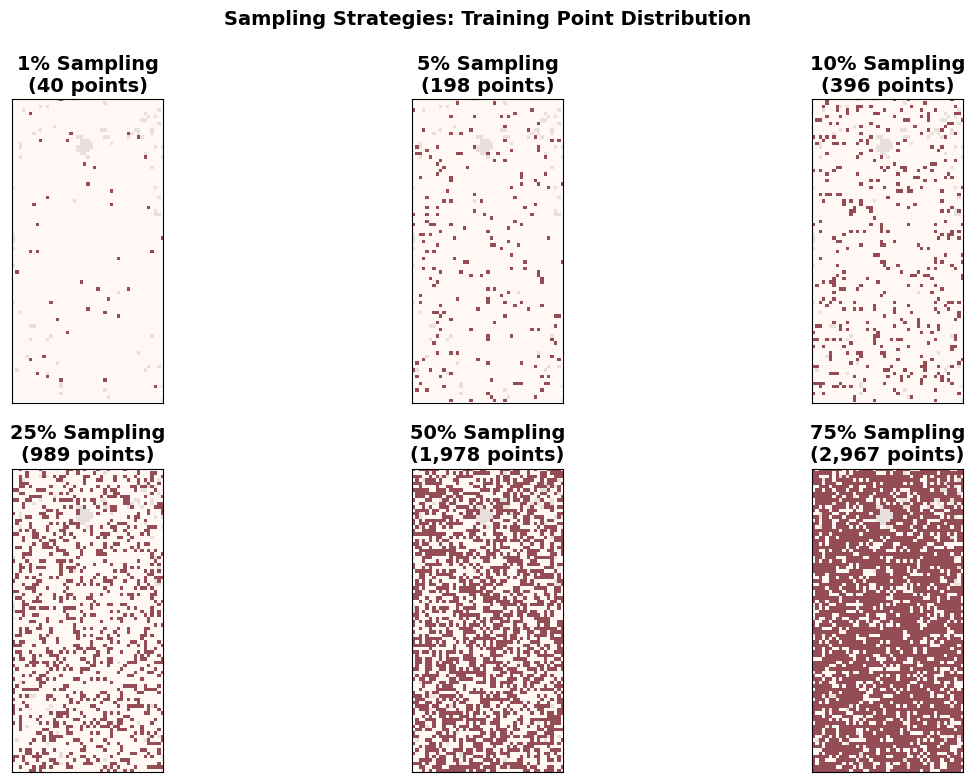

✓ Sampling visualization saved to: /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/01_sampling_patterns.png


In [7]:
# ============================================================================
# SECTION 4: Sampling Strategies & Sparse Masks
# ============================================================================

def create_sparse_mask(mask_full, sampling_fraction, seed=SEED):
    """
    Create sparse training mask by randomly selecting sampling_fraction of valid points.
    
    Args:
        mask_full: Full binary mask (H, W)
        sampling_fraction: Fraction of valid points to use [0, 1]
        seed: Random seed for reproducibility
        
    Returns:
        sparse_mask: Binary mask (H, W) with same shape as input
        selected_indices: 1D array of flat indices where mask_sparse == 1
    """
    rng = np.random.RandomState(seed)
    
    # Get indices of all valid points
    valid_indices = np.where(mask_full.flatten())[0]
    n_valid = len(valid_indices)
    
    # Sample points
    n_samples = max(1, int(np.ceil(sampling_fraction * n_valid)))
    selected_flat_indices = rng.choice(valid_indices, n_samples, replace=False)
    
    # Create sparse mask
    sparse_mask_flat = np.zeros(mask_full.size, dtype=np.float32)
    sparse_mask_flat[selected_flat_indices] = 1.0
    sparse_mask = sparse_mask_flat.reshape(mask_full.shape)
    
    return sparse_mask, selected_flat_indices


# Create sparse masks for all sampling fractions
sparse_masks = {}
sampled_indices = {}

print("\n" + "="*70)
print("SAMPLING STRATEGY: SPARSE TRAINING MASKS")
print("="*70)
for frac in config["sampling_fractions"]:
    sparse_mask, indices = create_sparse_mask(mask, frac, seed=SEED + int(frac * 1000))
    sparse_masks[frac] = torch.tensor(sparse_mask.flatten(), dtype=torch.float32, device=device)
    sampled_indices[frac] = indices
    
    n_train = sparse_mask.sum()
    n_valid = mask.sum()
    print(f"  {frac*100:5.0f}%: {int(n_train):6,d} / {int(n_valid):6,d} points → spatial coverage: {100*n_train/mask.size:.1f}%")

# Visualize sampling patterns
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Sampling Strategies: Training Point Distribution', fontsize=14, fontweight='bold')

for idx, frac in enumerate(config["sampling_fractions"]):
    ax = axes.flat[idx]
    
    # Show the full mask in light gray
    ax.imshow(mask, cmap='gray', alpha=0.3, origin='lower')
    
    # Overlay sparse mask
    sparse_mask_np = sparse_masks[frac].cpu().numpy().reshape(H, W)
    ax.imshow(sparse_mask_np, cmap='Reds', alpha=0.7, origin='lower')
    
    n_train = sparse_mask_np.sum()
    ax.set_title(f'{frac*100:.0f}% Sampling\n({int(n_train):,} points)', fontweight='bold', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig(out_dir / "01_sampling_patterns.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Sampling visualization saved to: {out_dir / '01_sampling_patterns.png'}")

In [8]:
# ============================================================================
# SECTION 5: Physics-Informed Loss (autodiff @ collocation points)
#   - Elastic equilibrium  div(sigma) = 0   (Hooke's law, plane stress)
#   - Saint-Venant compatibility  d2_yy e_xx + d2_xx e_yy - 2 d2_xy e_xy = 0
# Spatial derivatives are obtained by reverse-mode automatic differentiation of
# the network w.r.t. its input coordinate (no finite-difference stencil).
# ============================================================================

def compute_stress_from_strain(e_xx, e_yy, e_xy, E, nu):
    """Plane-stress linear elasticity.
        sigma_xx = E/(1-nu^2) (e_xx + nu e_yy)
        sigma_yy = E/(1-nu^2) (e_yy + nu e_xx)
        sigma_xy = E/(2(1+nu)) e_xy = G e_xy
    """
    factor = E / (1.0 - nu ** 2)
    sigma_xx = factor * (e_xx + nu * e_yy)
    sigma_yy = factor * (e_yy + nu * e_xx)
    G = E / (2.0 * (1.0 + nu))
    sigma_xy = G * e_xy
    return sigma_xx, sigma_yy, sigma_xy


def _grad(outputs, inputs):
    """First derivative d outputs / d inputs with graph retained for higher order."""
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs),
        create_graph=True, retain_graph=True)[0]


def physics_residuals_collocation(model, n_coll, device, cfg, extra_pts=None):
    """Equilibrium + compatibility residuals evaluated by autodiff at random
    collocation points in the unit square (normalised coordinates).

    Residuals are formed on the network's (scaled) strain outputs with the
    elastic operator non-dimensionalised by E/(1-nu^2) ('normalize_physics_by_E'),
    so the equilibrium and compatibility terms are O(1) and commensurate with the
    data MSE. Returns (L_equil, L_compat) as scalar mean-squared residuals.
    """
    nu = cfg["nu"]
    pts = torch.rand(n_coll, 2, device=device)
    if extra_pts is not None and extra_pts.numel() > 0:
        pts = torch.cat([pts, extra_pts.to(device)], dim=0)
    pts = pts.detach().requires_grad_(True)

    out = model(pts)
    e_xx, e_yy, e_xy = out[:, 0], out[:, 1], out[:, 2]

    g_xx = _grad(e_xx, pts); g_yy = _grad(e_yy, pts); g_xy = _grad(e_xy, pts)
    exx_x, exx_y = g_xx[:, 0], g_xx[:, 1]
    eyy_x, eyy_y = g_yy[:, 0], g_yy[:, 1]
    exy_x, exy_y = g_xy[:, 0], g_xy[:, 1]

    # dimensionless stress gradients (sigma / [E/(1-nu^2)])
    sxx_x = exx_x + nu * eyy_x
    syy_y = eyy_y + nu * exx_y
    syy_x = eyy_x + nu * exx_x
    c_xy  = (1.0 - nu) * 0.5                # sigma_xy / [E/(1-nu^2)] = (1-nu)/2 * e_xy
    sxy_x = c_xy * exy_x
    sxy_y = c_xy * exy_y

    eq1 = sxx_x + sxy_y                      # d_x sigma_xx + d_y sigma_xy
    eq2 = sxy_x + syy_y                      # d_x sigma_xy + d_y sigma_yy
    L_equil = (eq1 ** 2 + eq2 ** 2).mean()

    # second derivatives for Saint-Venant compatibility
    exx_yy = _grad(exx_y, pts)[:, 1]
    eyy_xx = _grad(eyy_x, pts)[:, 0]
    exy_xy = _grad(exy_x, pts)[:, 1]
    L_compat = (exx_yy + eyy_xx - 2.0 * exy_xy).pow(2).mean()

    return L_equil, L_compat


def grid_physics_diagnostics(e_xx_map, e_yy_map, e_xy_map, valid_mask, cfg):
    """Physical-unit physics-consistency diagnostics on a dense (H,W) strain map.
    Uses central finite differences on the reconstructed grid so the SAME operator
    can score networks (PINN, SIREN-only) and non-network baselines (CS, GP).

        R_equil  : sqrt(mean[ (d_x sx + d_y sxy)^2 + (d_x sxy + d_y syy)^2 ])  [GPa/um]
        R_compat : sqrt(mean[ (d2_yy exx + d2_xx eyy - 2 d2_xy exy)^2 ])       [1/um^2]
    """
    E_GPa = cfg["E"] / 1e9
    nu    = cfg["nu"]
    px    = cfg["px_um"]                      # um/pixel  -> derivatives per um

    sxx, syy, sxy = compute_stress_from_strain(e_xx_map, e_yy_map, e_xy_map, E_GPa, nu)
    # np.gradient(.., px) returns (d/dy, d/dx) for a (row=y, col=x) array
    dsxx_dy, dsxx_dx = np.gradient(sxx, px)
    dsyy_dy, dsyy_dx = np.gradient(syy, px)
    dsxy_dy, dsxy_dx = np.gradient(sxy, px)
    eq1 = dsxx_dx + dsxy_dy
    eq2 = dsxy_dx + dsyy_dy

    exx_y, exx_x = np.gradient(e_xx_map, px)
    eyy_y, eyy_x = np.gradient(e_yy_map, px)
    exy_y, exy_x = np.gradient(e_xy_map, px)
    exx_yy = np.gradient(exx_y, px, axis=0)
    eyy_xx = np.gradient(eyy_x, px, axis=1)
    exy_xy = np.gradient(exy_x, px, axis=0)
    comp = exx_yy + eyy_xx - 2.0 * exy_xy

    m = valid_mask > 0.5
    R_equil  = float(np.sqrt(np.mean(eq1[m] ** 2 + eq2[m] ** 2)))
    R_compat = float(np.sqrt(np.mean(comp[m] ** 2)))
    return R_equil, R_compat


def normalized_physics(L_eq, L_co, cfg, ema_state):
    """[FIX] Divide each residual by a running (EMA) estimate of its own magnitude,
    with the EMA FROZEN after cfg["phys_norm_warmup"] steps. The warmup sets the
    scale so physics gradients are commensurate with the O(1) data-MSE term
    (raw residuals on standardised fields are O(1e2)-O(1e4) and otherwise crush
    the data term); freezing afterwards makes the physics term a fixed-scale
    penalty whose pull decays as the residual shrinks. A live EMA keeps the pull
    constant — equivalent to minimising log L — and eventually grinds the network
    into the trivial flat-field solution once the data loss plateaus.
    Set cfg["normalize_residuals"]=False to reproduce the original behaviour."""
    if not cfg.get("normalize_residuals", False):
        return cfg["alpha_eq"] * L_eq + cfg["alpha_co"] * L_co
    ema_state["n"] = ema_state.get("n", 0) + 1
    if ema_state["n"] <= cfg.get("phys_norm_warmup", 200):
        for key, L in (("eq", L_eq), ("co", L_co)):
            v = float(L.detach())
            ema_state[key] = v if key not in ema_state else 0.99 * ema_state[key] + 0.01 * v
    return (cfg["alpha_eq"] * L_eq / (ema_state["eq"] + 1e-12)
            + cfg["alpha_co"] * L_co / (ema_state["co"] + 1e-12))


def pinn_loss_with_physics(model, x, y, e_xx_true, e_yy_true, e_xy_true, theta_true,
                           sparse_mask, H, W, device, cfg, ema_state=None, lam_ramp=1.0):
    """Fixed-weight data + collocation-physics loss.
    Retained for the Bayesian variants (Section 10); the deterministic training
    loop below uses its own ramped objective.
    """
    idx = sparse_mask > 0.5
    inp = torch.stack([x[idx], y[idx]], dim=1)
    out = model(inp)
    tgt = torch.stack([e_xx_true[idx], e_yy_true[idx], e_xy_true[idx], theta_true[idx]], dim=1)
    loss_data = ((out - tgt) ** 2).mean()

    L_eq, L_co = physics_residuals_collocation(model, cfg["n_collocation"], device, cfg)
    loss_phys = normalized_physics(L_eq, L_co, cfg, ema_state if ema_state is not None else {})  # [FIX]
    total = cfg["w_data"] * loss_data + lam_ramp * cfg["lambda_phys_max"] * loss_phys  # [FIX] ramped
    return total, loss_data.detach(), loss_phys.detach()


print("✓ Physics-informed loss (autodiff equilibrium + Saint-Venant compatibility) defined")


✓ Physics-informed loss (autodiff equilibrium + Saint-Venant compatibility) defined


In [9]:
# ============================================================================
# SECTION 6: Residual-Based Adaptive Refinement (RAR) of collocation points
# Concentrates collocation density where the PDE residual is largest, the PINN
# analogue of adaptive mesh refinement. Operates on PHYSICS collocation points
# (it does not add measured data to the training set).
# ============================================================================

def adaptive_collocation_refinement(model, cfg, device, n_candidates=5000):
    """Draw a large random candidate set, score each point by its elastic-
    equilibrium residual, and return the top-(rar_pct * n_collocation) points to
    append to the persistent collocation pool.
    """
    nu = cfg["nu"]
    pts = torch.rand(n_candidates, 2, device=device, requires_grad=True)
    out = model(pts)
    e_xx, e_yy, e_xy = out[:, 0], out[:, 1], out[:, 2]
    g_xx = _grad(e_xx, pts); g_yy = _grad(e_yy, pts); g_xy = _grad(e_xy, pts)
    sxx_x = g_xx[:, 0] + nu * g_yy[:, 0]
    syy_y = g_yy[:, 1] + nu * g_xx[:, 1]
    c_xy  = (1.0 - nu) * 0.5
    sxy_x = c_xy * g_xy[:, 0]
    sxy_y = c_xy * g_xy[:, 1]
    resid = (sxx_x + sxy_y) ** 2 + (sxy_x + syy_y) ** 2

    k = max(1, int(cfg["rar_num_new_points_pct"] * cfg["n_collocation"]))
    k = min(k, resid.numel())
    idx = torch.topk(resid.detach(), k).indices
    return pts.detach()[idx]


print("✓ Residual-based adaptive collocation refinement (RAR) defined")


✓ Residual-based adaptive collocation refinement (RAR) defined


In [10]:
# ============================================================================
# SECTION 7: Main Training Loop (ramped physics weight + RAR + early stopping)
# ============================================================================

def train_pinn_sparse(sampling_fraction, sparse_mask, cfg, device, lambda_phys_scale=1.0):
    """Train one SIREN PINN on sparse data.

    lambda_phys_scale : multiplies the physics weight. Use 1.0 for the full PINN
                        and 0.0 for the data-only SIREN ablation (Section 4).

    Composite loss (Eq.):
        L = w_data * L_data
            + lambda_phys(t) * (alpha_eq * L_equil + alpha_co * L_compat)
        lambda_phys(t) = lambda_phys_max * (1 - exp(-t / tau)) * lambda_phys_scale

    Early stopping is on a held-out VALIDATION subset of the sampled points.
    """
    torch.manual_seed(SEED)
    model = create_pinn_model(cfg["architecture"], cfg["hidden_dim"],
                              cfg["num_layers"], cfg["skip_connections"],
                              omega_0=cfg["omega_0"]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=1e-6)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=cfg["lr_decay_interval"],
                                            gamma=cfg["lr_decay_factor"])

    # ---- train / validation split of the sampled probe positions ----
    samp_idx = torch.where(sparse_mask > 0.5)[0].cpu().numpy()
    rng = np.random.RandomState(SEED)
    rng.shuffle(samp_idx)
    n_val = max(1, int(cfg["val_fraction"] * len(samp_idx)))
    val_idx = samp_idx[:n_val]
    tr_idx  = samp_idx[n_val:] if len(samp_idx) - n_val > 0 else samp_idx
    tr_idx  = torch.as_tensor(tr_idx, dtype=torch.long, device=device)
    val_idx = torch.as_tensor(val_idx, dtype=torch.long, device=device)

    coords_all = torch.stack([x_flat, y_flat], dim=1)
    tr_in  = coords_all[tr_idx]
    val_in = coords_all[val_idx]
    tgt_all = torch.stack([e_xx_scaled, e_yy_scaled, e_xy_scaled, theta_scaled], dim=1)
    tr_tgt  = tgt_all[tr_idx]
    val_tgt = tgt_all[val_idx]

    history = {"epoch": [], "loss_total": [], "loss_data": [],
               "loss_physics": [], "val_loss": [], "lr": [], "lambda_phys": []}

    best_val = float("inf"); best_state = None; patience_counter = 0
    coll_pool = torch.empty(0, 2, device=device)
    ema_state = {}                      # [FIX] running scale of the physics residuals
    use_phys = lambda_phys_scale > 0.0

    desc = f"Train {sampling_fraction*100:.0f}%" + ("" if use_phys else " [data-only]")
    for epoch in trange(cfg["epochs"], desc=desc, leave=False):
        # RAR: grow the persistent collocation pool at high-residual regions
        if (use_phys and cfg["enable_rar"] and epoch >= cfg["rar_trigger_epoch"]
                and epoch % cfg["rar_interval"] == 0):
            new_pts = adaptive_collocation_refinement(model, cfg, device)
            coll_pool = torch.cat([coll_pool, new_pts], dim=0)
            cap = cfg["rar_max_pool_mult"] * cfg["n_collocation"]
            if coll_pool.shape[0] > cap:
                coll_pool = coll_pool[-cap:]

        model.train(); opt.zero_grad()
        pred = model(tr_in)
        loss_data = ((pred - tr_tgt) ** 2).mean()

        if use_phys:
            lam = cfg["lambda_phys_max"] * (1.0 - np.exp(-epoch / cfg["ramp_tau"])) * lambda_phys_scale
            L_eq, L_co = physics_residuals_collocation(
                model, cfg["n_collocation"], device, cfg,
                extra_pts=(coll_pool if coll_pool.numel() else None))
            loss_phys = normalized_physics(L_eq, L_co, cfg, ema_state)  # [FIX]
            total = cfg["w_data"] * loss_data + lam * loss_phys
        else:
            lam = 0.0
            loss_phys = torch.zeros((), device=device)
            total = cfg["w_data"] * loss_data

        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step(); sched.step()

        with torch.no_grad():
            model.eval()
            val_loss = ((model(val_in) - val_tgt) ** 2).mean().item()

        history["epoch"].append(epoch)
        history["loss_total"].append(total.item())
        history["loss_data"].append(loss_data.item())
        history["loss_physics"].append(float(loss_phys.item()))
        history["val_loss"].append(val_loss)
        history["lr"].append(sched.get_last_lr()[0])
        history["lambda_phys"].append(float(lam))

        if (best_val - val_loss) > cfg["min_delta"]:
            best_val = val_loss; patience_counter = 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        if cfg["early_stop"] and patience_counter >= cfg["patience"]:
            if cfg["verbose"]:
                print(f"      -> early stop @ epoch {epoch} (best val loss {best_val:.4e})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("TRAINING: PINNs across sampling fractions (autodiff physics + ramp + RAR)")
print("="*70)

trained_models     = {}
training_histories = {}
training_times     = {}

start_time_total = time.time()
for frac in config["sampling_fractions"]:
    print(f"\n▶ TRAINING on {frac*100:.0f}% data ...")
    t0 = time.time()
    model, history = train_pinn_sparse(frac, sparse_masks[frac], config, device,
                                       lambda_phys_scale=1.0)
    elapsed = time.time() - t0
    trained_models[frac]     = model
    training_histories[frac] = history
    training_times[frac]     = elapsed
    print(f"  ✓ {elapsed:.1f}s | {len(history['epoch'])} epochs | "
          f"final loss {history['loss_total'][-1]:.4e} | best val {min(history['val_loss']):.4e}")

total_time = time.time() - start_time_total
print(f"\n✓ All PINN training completed in {total_time:.1f}s")



TRAINING: PINNs across sampling fractions (autodiff physics + ramp + RAR)

▶ TRAINING on 1% data ...


Train 1%:   0%|          | 0/5000 [00:00<?, ?it/s]

Train 1%:   0%|          | 1/5000 [00:00<20:15,  4.11it/s]

Train 1%:   0%|          | 4/5000 [00:00<06:23, 13.02it/s]

Train 1%:   0%|          | 7/5000 [00:00<04:39, 17.85it/s]

...

Train 75%:  19%|█▉        | 962/5000 [00:33<02:20, 28.69it/s]

Train 75%:  19%|█▉        | 965/5000 [00:33<02:20, 28.71it/s]

Train 75%:  19%|█▉        | 968/5000 [00:33<02:20, 28.70it/s]

Train 75%:  19%|█▉        | 971/5000 [00:33<02:20, 28.66it/s]

      -> early stop @ epoch 972 (best val loss 7.7656e-01)
  ✓ 33.9s | 973 epochs | final loss 2.4605e-01 | best val 7.7656e-01

✓ All PINN training completed in 160.2s


In [11]:
# ============================================================================
# SECTION 8: Evaluation & Metrics Computation
# ============================================================================

def evaluate_model(model, x, y, e_xx_true, e_yy_true, e_xy_true, theta_true,
                   mask_eval, H, W, device):
    """
    Evaluate model and compute comprehensive metrics.
    
    Returns:
        predictions: Dict of predicted strain components
        metrics: Dict of per-component metrics
    """
    with torch.no_grad():
        inputs = torch.stack([x, y], dim=1)
        outputs = model(inputs)
        e_xx_pred_s, e_yy_pred_s, e_xy_pred_s, theta_pred_s = outputs[:, 0], outputs[:, 1], outputs[:, 2], outputs[:, 3]
    
    # Unscale predictions
    e_xx_pred = unscale(e_xx_pred_s, 'e_xx')
    e_yy_pred = unscale(e_yy_pred_s, 'e_yy')
    e_xy_pred = unscale(e_xy_pred_s, 'e_xy')
    theta_pred = unscale(theta_pred_s, 'theta')
    
    # Move to CPU for numpy operations
    e_xx_pred_np = e_xx_pred.cpu().numpy().reshape(H, W)
    e_yy_pred_np = e_yy_pred.cpu().numpy().reshape(H, W)
    e_xy_pred_np = e_xy_pred.cpu().numpy().reshape(H, W)
    theta_pred_np = theta_pred.cpu().numpy().reshape(H, W)
    
    predictions = {
        'e_xx': e_xx_pred_np,
        'e_yy': e_yy_pred_np,
        'e_xy': e_xy_pred_np,
        'theta': theta_pred_np,
    }
    
    # Compute metrics per component
    metrics = {}
    for name, pred, true in [
        ('e_xx', e_xx_pred_np, e_xx),
        ('e_yy', e_yy_pred_np, e_yy),
        ('e_xy', e_xy_pred_np, e_xy),
        ('theta', theta_pred_np, theta),
    ]:
        valid_idx = mask_eval > 0.5
        pred_valid = pred[valid_idx]
        true_valid = true[valid_idx]
        
        mse = np.mean((pred_valid - true_valid) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(pred_valid - true_valid))
        max_err = np.max(np.abs(pred_valid - true_valid))
        
        # R² score
        ss_res = np.sum((true_valid - pred_valid) ** 2)
        ss_tot = np.sum((true_valid - np.mean(true_valid)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
        
        # Normalized RMSE
        range_true = np.max(true_valid) - np.min(true_valid)
        nrmse_range = rmse / range_true if range_true > 0 else 0.0
        
        std_true = np.std(true_valid)
        nrmse_std = rmse / std_true if std_true > 0 else 0.0
        
        metrics[name] = {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'Max Error': max_err,
            'R²': r2,
            'NRMSE (range)': nrmse_range,
            'NRMSE (std)': nrmse_std,
        }
    
    return predictions, metrics


# Evaluate all models
print("\n" + "="*70)
print("EVALUATION: Computing Metrics Across All Models")
print("="*70)

all_predictions = {}
all_metrics = {}

for frac in config["sampling_fractions"]:
    print(f"  Evaluating {frac*100:.0f}%...")
    preds, metrics = evaluate_model(trained_models[frac], x_flat, y_flat,
                                   e_xx, e_yy, e_xy, theta,
                                   mask, H, W, device)
    all_predictions[frac] = preds
    all_metrics[frac] = metrics

print("✓ Evaluation complete")

# Create metrics summary table
print("\nMetrics Summary (R² Score):")
r2_summary = pd.DataFrame({
    'Sampling %': [f'{f*100:.0f}%' for f in config["sampling_fractions"]],
    'e_xx': [all_metrics[f]['e_xx']['R²'] for f in config["sampling_fractions"]],
    'e_yy': [all_metrics[f]['e_yy']['R²'] for f in config["sampling_fractions"]],
    'e_xy': [all_metrics[f]['e_xy']['R²'] for f in config["sampling_fractions"]],
    'theta': [all_metrics[f]['theta']['R²'] for f in config["sampling_fractions"]],
})
print(r2_summary.to_string(index=False))

print("\nMetrics Summary (RMSE):")
rmse_summary = pd.DataFrame({
    'Sampling %': [f'{f*100:.0f}%' for f in config["sampling_fractions"]],
    'e_xx': [all_metrics[f]['e_xx']['RMSE'] for f in config["sampling_fractions"]],
    'e_yy': [all_metrics[f]['e_yy']['RMSE'] for f in config["sampling_fractions"]],
    'e_xy': [all_metrics[f]['e_xy']['RMSE'] for f in config["sampling_fractions"]],
    'theta': [all_metrics[f]['theta']['RMSE'] for f in config["sampling_fractions"]],
})
print(rmse_summary.to_string(index=False))


EVALUATION: Computing Metrics Across All Models
  Evaluating 1%...
  Evaluating 5%...
  Evaluating 10%...
  Evaluating 25%...
  Evaluating 50%...
  Evaluating 75%...
✓ Evaluation complete

Metrics Summary (R² Score):
Sampling %      e_xx      e_yy      e_xy     theta
        1% -0.132770 -0.169188 -0.192070 -0.297595
        5% -0.087410  0.058979 -0.058201 -0.041462
       10%  0.062005  0.364931  0.214370  0.192473
       25%  0.113101  0.416548  0.285226  0.258687
       50%  0.420472  0.575671  0.491310  0.451419
       75%  0.506045  0.669454  0.650103  0.652432

Metrics Summary (RMSE):
Sampling %     e_xx     e_yy     e_xy    theta
        1% 0.131906 0.035600 0.054687 0.057576
        5% 0.129238 0.031938 0.051525 0.051582
       10% 0.120031 0.026237 0.044396 0.045421
       25% 0.116716 0.025149 0.042347 0.043519
       50% 0.094348 0.021447 0.035724 0.037437
       75% 0.087104 0.018929 0.029628 0.029799


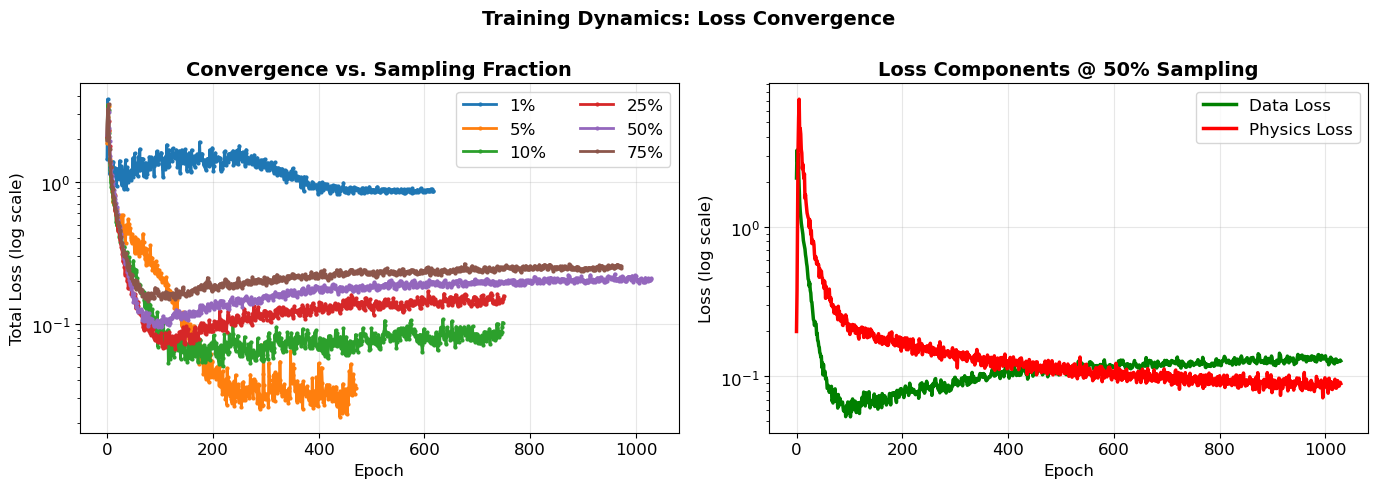

✓ Loss curves saved to: /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/02_loss_convergence.png


In [12]:
# ============================================================================
# SECTION 9: Visualization & Comparison
# ============================================================================

# 1. Loss curves for each sampling fraction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Dynamics: Loss Convergence', fontsize=14, fontweight='bold')

ax = axes[0]
for frac in config["sampling_fractions"]:
    history = training_histories[frac]
    ax.semilogy(history['epoch'], history['loss_total'], marker='o', markersize=2, 
               label=f'{frac*100:.0f}%', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Total Loss (log scale)', fontsize=12)
ax.set_title('Convergence vs. Sampling Fraction', fontweight='bold')
ax.legend(loc='best', ncol=2)
ax.grid(True, alpha=0.3)

# Data vs. Physics loss breakdown for one model (50%)
ax = axes[1]
frac = 0.50
history = training_histories[frac]
ax.semilogy(history['epoch'], history['loss_data'], label='Data Loss', linewidth=2.5, color='green')
ax.semilogy(history['epoch'], history['loss_physics'], label='Physics Loss', linewidth=2.5, color='red')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title(f'Loss Components @ 50% Sampling', fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / "02_loss_convergence.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Loss curves saved to: {out_dir / '02_loss_convergence.png'}")

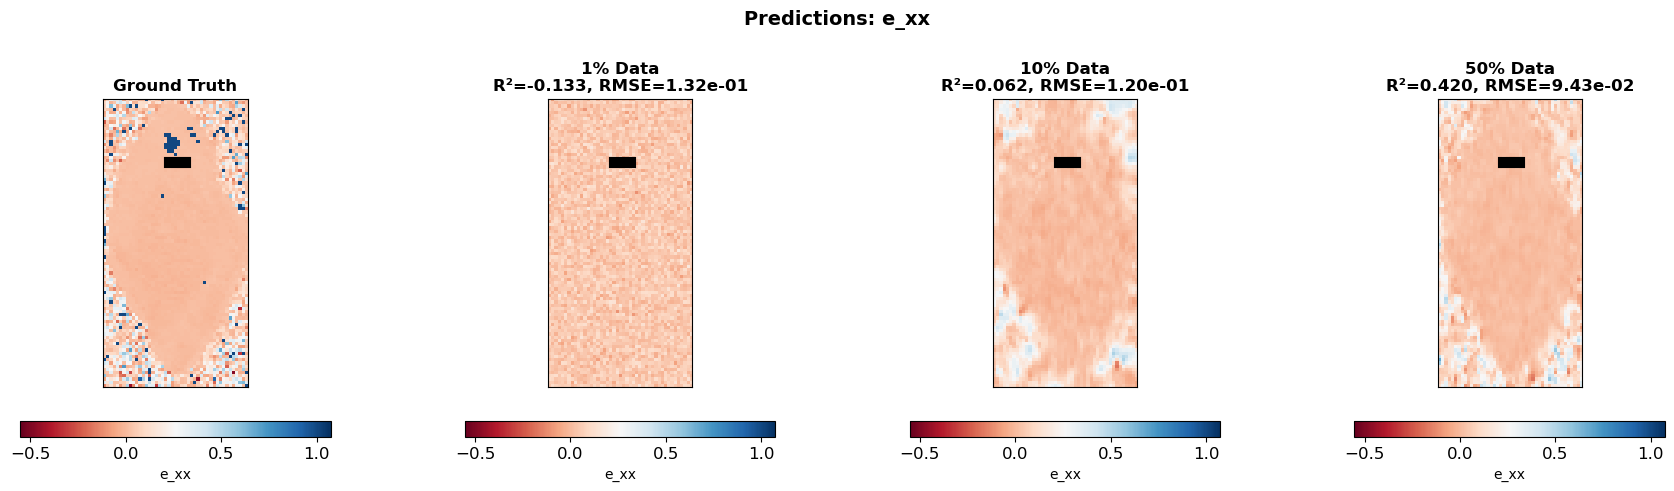

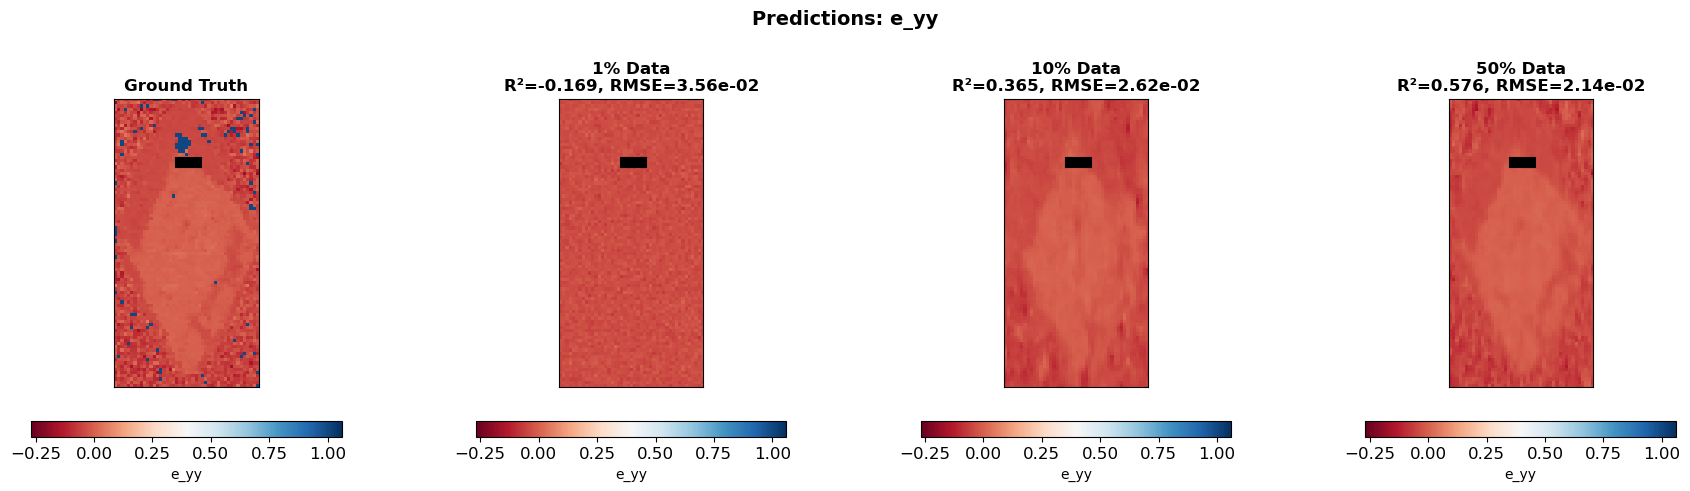

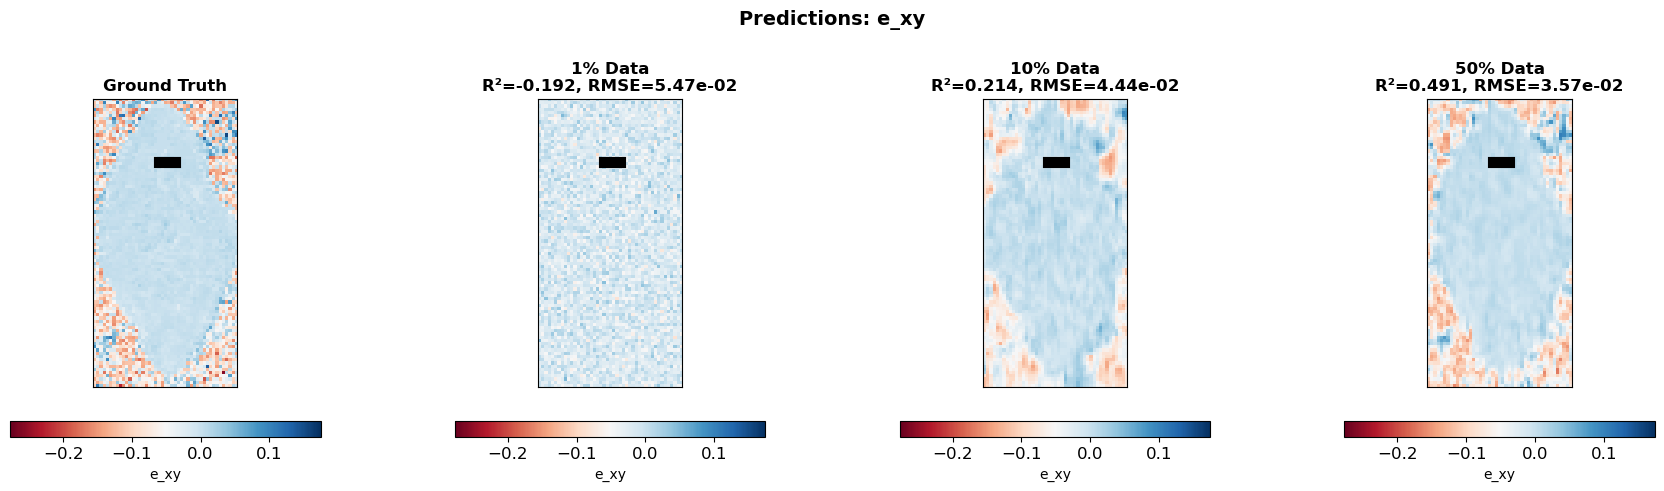

✓ Prediction maps with consistent colorbars and scale bars (nm) saved
  Calibration: 17.87 nm/pixel


In [13]:
# 2. Side-by-side predictions for selected fractions with consistent colorbars
selected_fracs = [0.01, 0.10, 0.50]

# Pixel-to-nm calibration from metadata
# Real space pixel size: 0.017872741 µm = 17.872741 nm/pixel
calibration_nm_per_pixel = 0.017872741 * 1000  # Convert µm to nm

for component, true_data in [('e_xx', e_xx), ('e_yy', e_yy), ('e_xy', e_xy)]:
    fig, axes = plt.subplots(1, len(selected_fracs) + 1, figsize=(18, 5))
    fig.suptitle(f'Predictions: {component}', fontsize=14, fontweight='bold')
    
    # Compute consistent vmin/vmax across ALL data (ground truth + all predictions)
    all_data = [true_data] + [all_predictions[frac][component] for frac in selected_fracs]
    valid_mask = np.isfinite(true_data)
    vmin = np.nanmin([np.nanmin(arr[valid_mask]) for arr in all_data])
    vmax = np.nanmax([np.nanmax(arr[valid_mask]) for arr in all_data])
    
    # Add 5% padding to the range for better contrast
    range_val = vmax - vmin
    vmin -= 0.05 * range_val
    vmax += 0.05 * range_val
    
    # Ground truth
    ax = axes[0]
    im = ax.imshow(true_data, cmap='RdBu', origin='lower', vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, ax=ax, location='bottom', pad=0.1, fraction=0.046)
    cbar.set_label(component, fontsize=10)
    ax.set_title('Ground Truth', fontweight='bold', fontsize=12)
    # ax.set_xlabel('x (nm)', fontsize=9)
    # ax.set_ylabel('y (nm)', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add scale bar to ground truth (in nm, no label)
    scale_length_px = W // 8  # 1/8 of width in pixels
    scale_length_nm = scale_length_px * calibration_nm_per_pixel
    bar_x_start = W - scale_length_px - 20
    bar_x_end = W - 20
    bar_y = H - 20
    ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y], 'k-', linewidth=8)
    
    # Predictions at each sampling fraction
    for idx, frac in enumerate(selected_fracs):
        ax = axes[idx + 1]
        pred = all_predictions[frac][component]
        im = ax.imshow(pred, cmap='RdBu', origin='lower', vmin=vmin, vmax=vmax)
        cbar = plt.colorbar(im, ax=ax, location='bottom', pad=0.1, fraction=0.046)
        cbar.set_label(component, fontsize=10)
        
        r2 = all_metrics[frac][component]['R²']
        rmse = all_metrics[frac][component]['RMSE']
        ax.set_title(f'{frac*100:.0f}% Data\nR²={r2:.3f}, RMSE={rmse:.2e}', 
                     fontweight='bold', fontsize=12)
        # ax.set_xlabel('x (nm)', fontsize=9)
        # ax.set_ylabel('y (nm)', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add scale bar (in nm, no label)
        ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y], 'k-', linewidth=8)
    
    plt.tight_layout()
    plt.savefig(out_dir / f"03_predictions_{component}.png", dpi=300, bbox_inches='tight')
    plt.show()

print(f"✓ Prediction maps with consistent colorbars and scale bars (nm) saved")
print(f"  Calibration: {calibration_nm_per_pixel:.2f} nm/pixel")

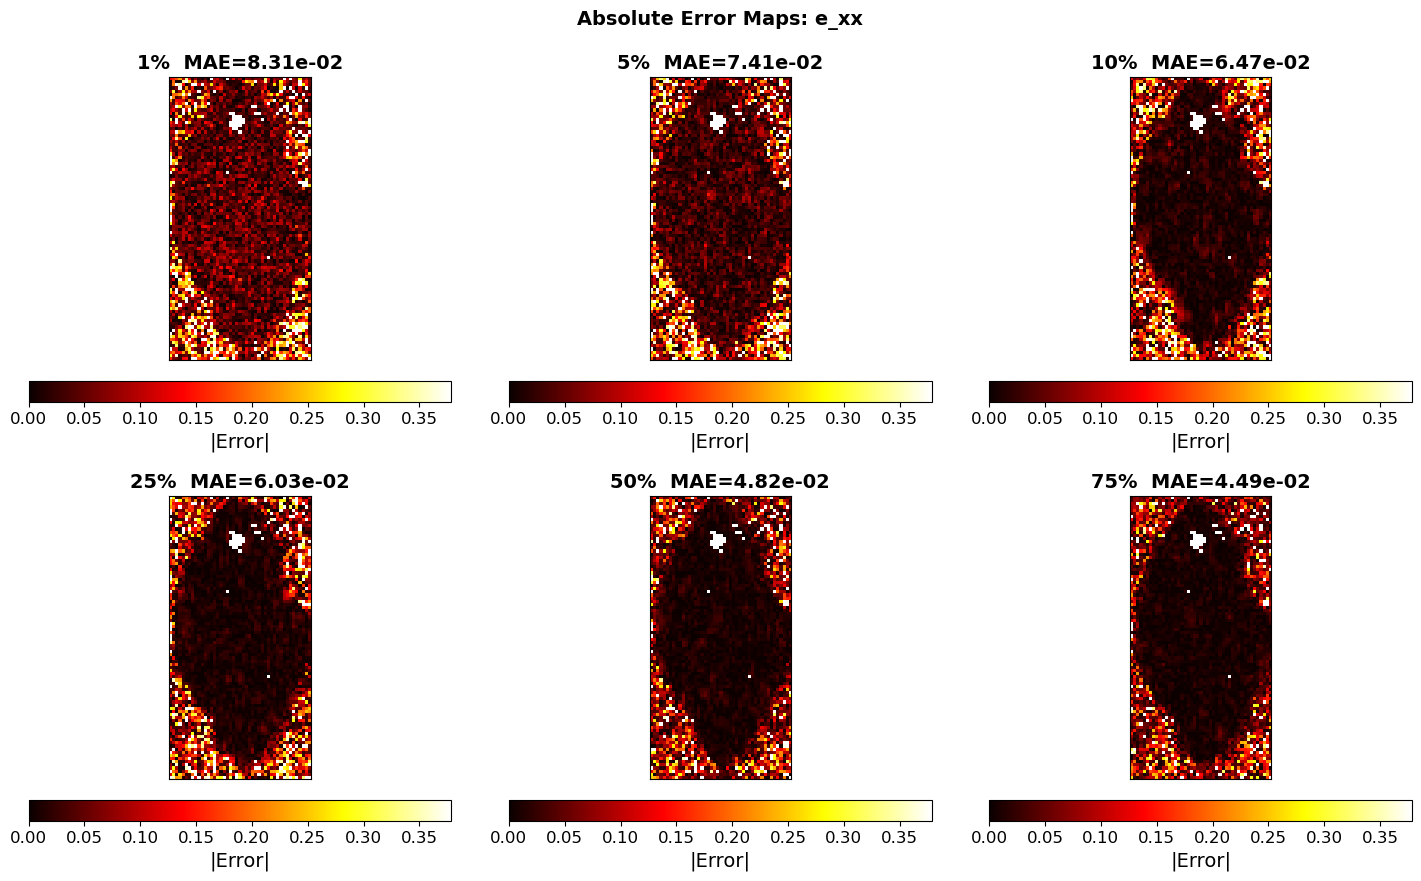

✓ Error heatmaps saved (shared scale, vmax=0.379)


In [14]:
# 3. Error heatmaps (shared color scale across sampling fractions, for fair comparison)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Absolute Error Maps: e_xx', fontsize=14, fontweight='bold')

error_maps = {frac: np.abs(all_predictions[frac]['e_xx'] - e_xx) for frac in config["sampling_fractions"]}
vmax_e = np.nanpercentile(np.concatenate([e[mask > 0.5] for e in error_maps.values()]), 98)

for idx, frac in enumerate(config["sampling_fractions"]):
    ax = axes.flat[idx]
    im = ax.imshow(error_maps[frac], cmap='hot', origin='lower', vmin=0, vmax=vmax_e)
    cbar = plt.colorbar(im, ax=ax, location='bottom', pad=0.06, shrink=0.85)
    cbar.set_label('|Error|', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    
    mae = all_metrics[frac]['e_xx']['MAE']
    max_err = all_metrics[frac]['e_xx']['Max Error']
    ax.set_title(f'{frac*100:.0f}%  MAE={mae:.2e}', fontweight='bold', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig(out_dir / "04_error_heatmaps_exx.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Error heatmaps saved (shared scale, vmax={vmax_e:.3g})")

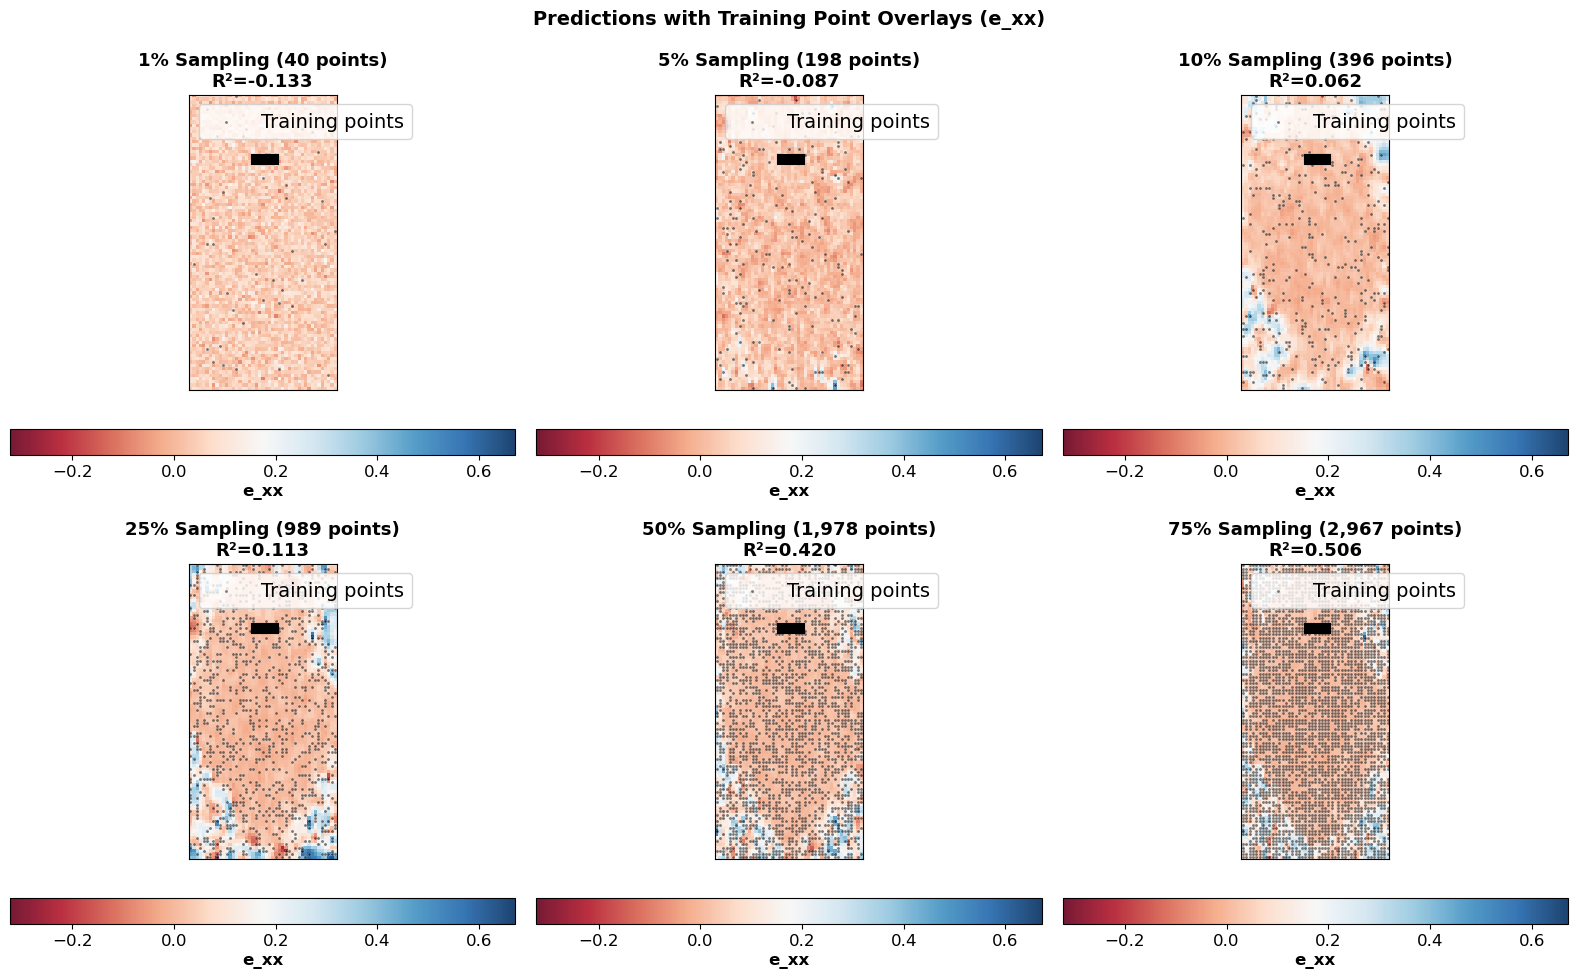

✓ Predictions with sampling overlay saved to: /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/07_predictions_with_sampling_overlay.png
  Calibration: 17.87 nm/pixel
  Colorbar range: -3.2228e-01 to 6.7113e-01 (consistent across all fractions)


In [15]:
# ============================================================================
# Overlay Sampling Points on Predictions
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Predictions with Training Point Overlays (e_xx)', fontsize=14, fontweight='bold')

selected_fracs = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75]

# Pixel-to-nm calibration
calibration_nm_per_pixel = 0.017872741 * 1000  # Convert µm to nm

# Compute consistent colorbar range across all fractions
all_preds = [all_predictions[frac]['e_xx'] for frac in selected_fracs]
valid_mask = mask > 0.5
all_valid_preds = np.concatenate([pred[valid_mask] for pred in all_preds])
vmin_global = np.nanmin(all_valid_preds)
vmax_global = np.nanmax(all_valid_preds)

for idx, frac in enumerate(selected_fracs):
    ax = axes.flat[idx]
    
    # Get predictions for this fraction
    e_xx_pred = all_predictions[frac]['e_xx']
    
    # Show prediction map with consistent colorbar range
    im = ax.imshow(e_xx_pred, cmap='RdBu', origin='lower', vmin=vmin_global, vmax=vmax_global, alpha=0.9)
    
    # Overlay training points as black dots
    sparse_mask_np = sparse_masks[frac].cpu().numpy().reshape(H, W)
    y_pts, x_pts = np.where(sparse_mask_np > 0.5)
    ax.scatter(x_pts, y_pts, c='black', s=5, alpha=0.5, edgecolors='white', linewidths=0.3, label='Training points')

    # Add colorbar with larger label fontsize
    cbar = plt.colorbar(im, ax=ax, label='e_xx', location='bottom', pad=0.1)
    cbar.set_label('e_xx', fontsize=12, fontweight='bold')
    
    n_train = int(sparse_mask_np.sum())
    ax.set_title(f'{frac*100:.0f}% Sampling ({n_train:,} points)\nR²={all_metrics[frac]["e_xx"]["R²"]:.3f}', 
                 fontweight='bold', fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='upper left', fontsize=14)
    
    # Add scale bar (in nm, no label)
    scale_length_px = W // 8  # 1/8 of width in pixels
    bar_x_start = W - scale_length_px - 20
    bar_x_end = W - 20
    bar_y = H - 20
    ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y], 'k-', linewidth=8)

plt.tight_layout()
plt.savefig(out_dir / "07_predictions_with_sampling_overlay.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Predictions with sampling overlay saved to: {out_dir / '07_predictions_with_sampling_overlay.png'}")
print(f"  Calibration: {calibration_nm_per_pixel:.2f} nm/pixel")
print(f"  Colorbar range: {vmin_global:.4e} to {vmax_global:.4e} (consistent across all fractions)")


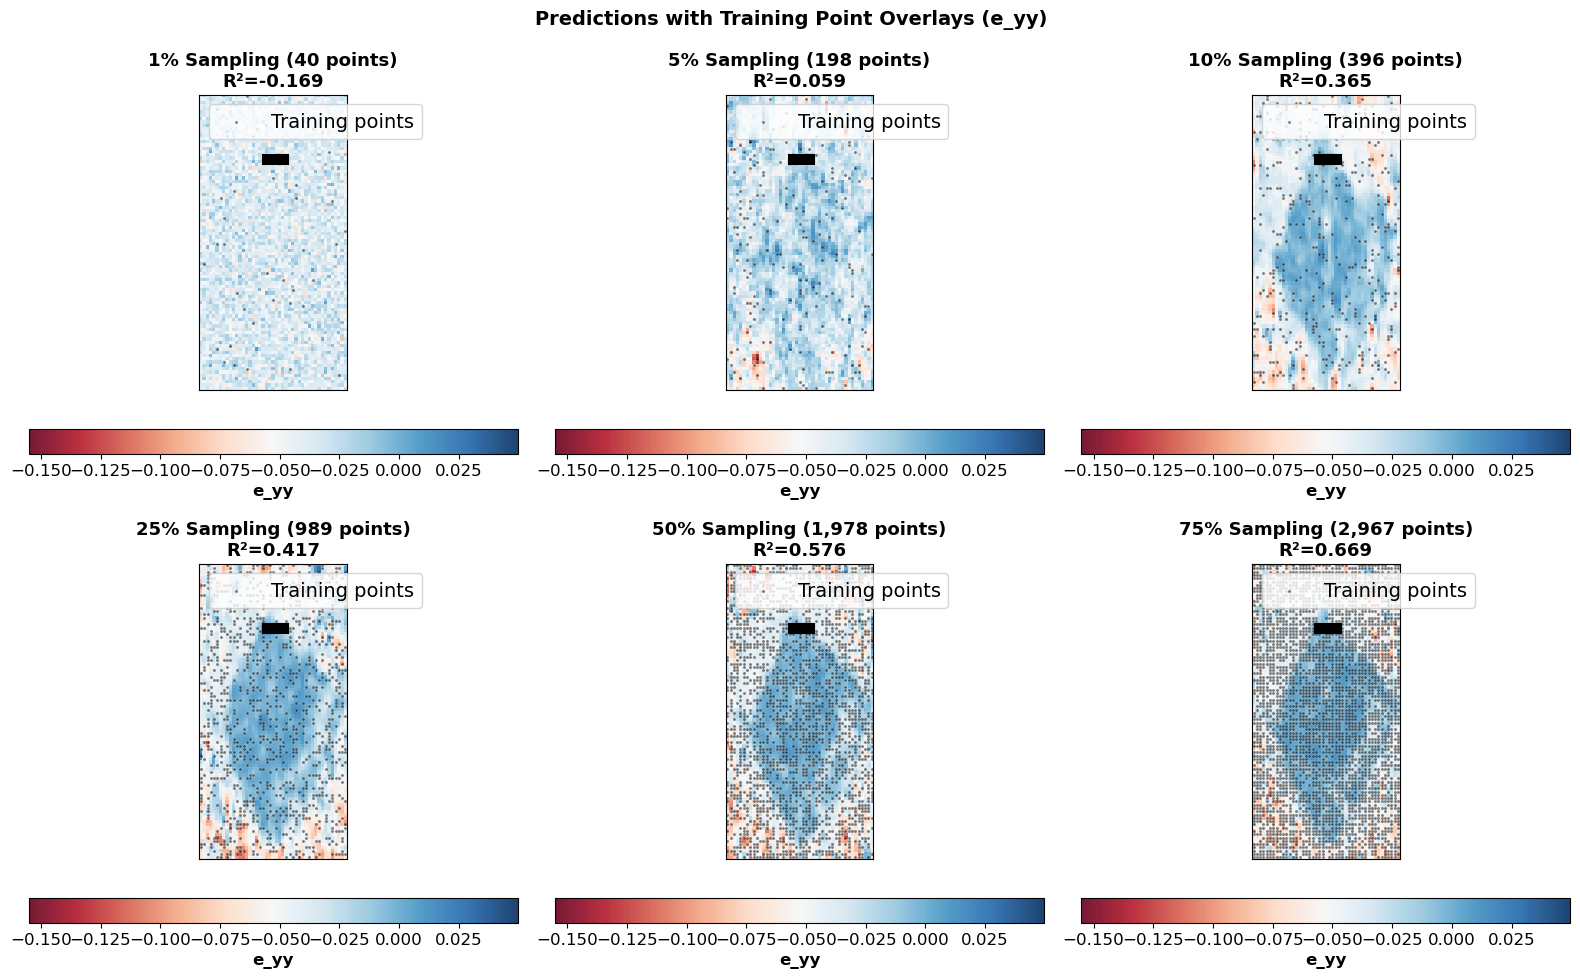

✓ Predictions with sampling overlay saved to: /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/07b_predictions_with_sampling_overlay_eyy.png
  Calibration: 17.87 nm/pixel
  Colorbar range: -1.5507e-01 to 4.9589e-02 (consistent across all fractions)


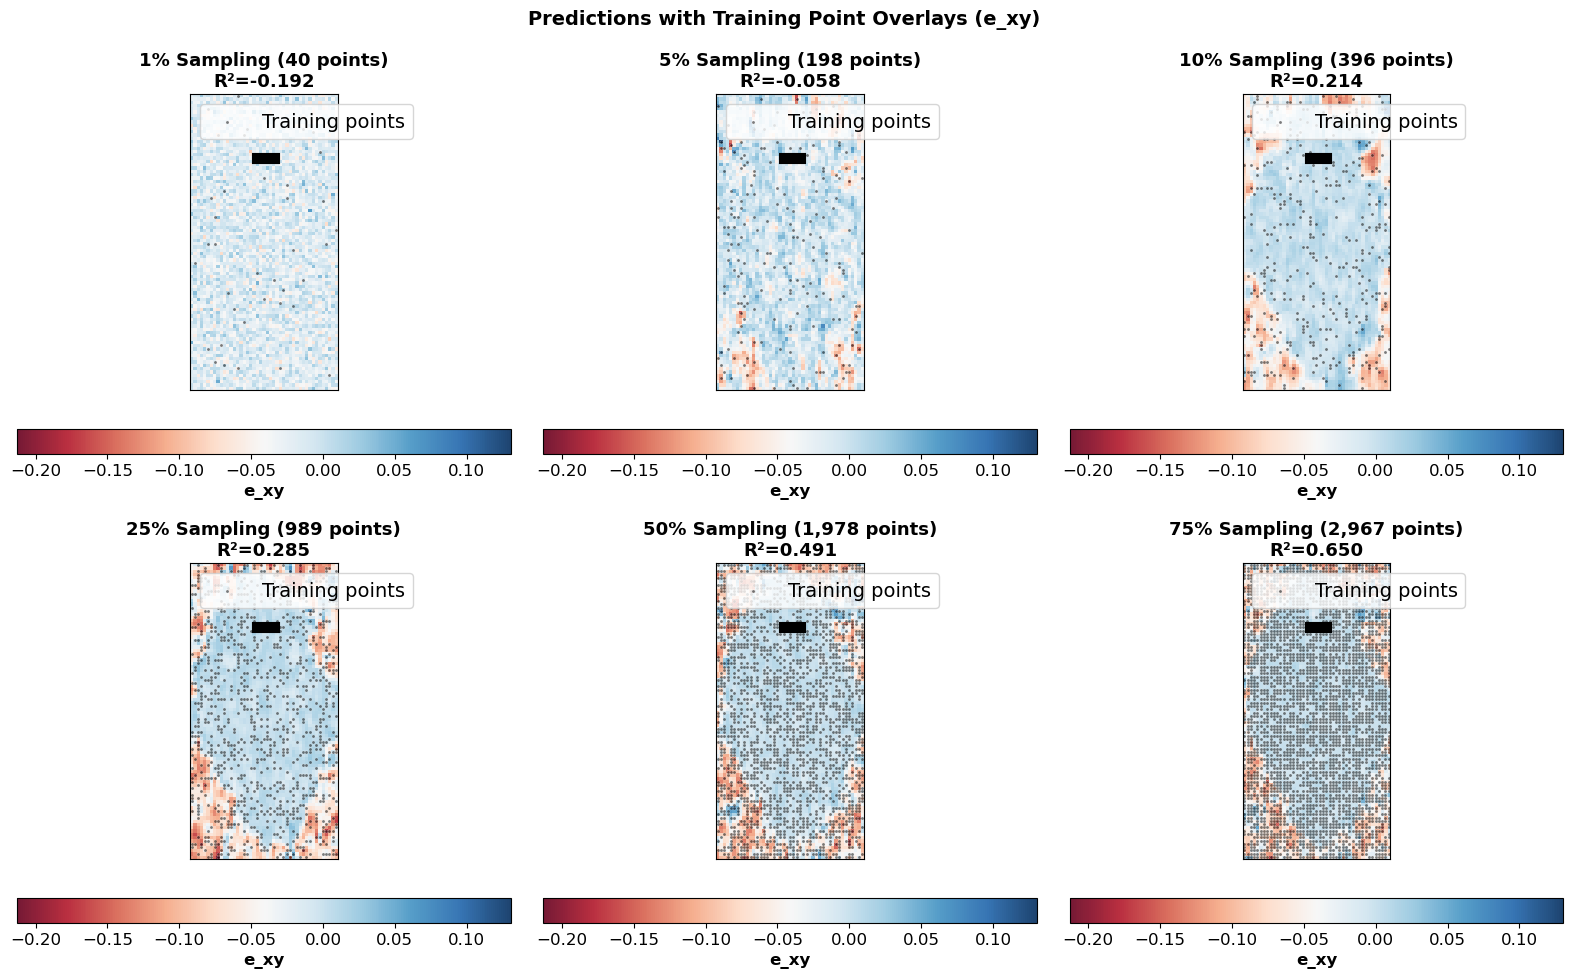

✓ Predictions with sampling overlay saved to: /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/07c_predictions_with_sampling_overlay_exy.png
  Calibration: 17.87 nm/pixel
  Colorbar range: -2.1286e-01 to 1.3043e-01 (consistent across all fractions)


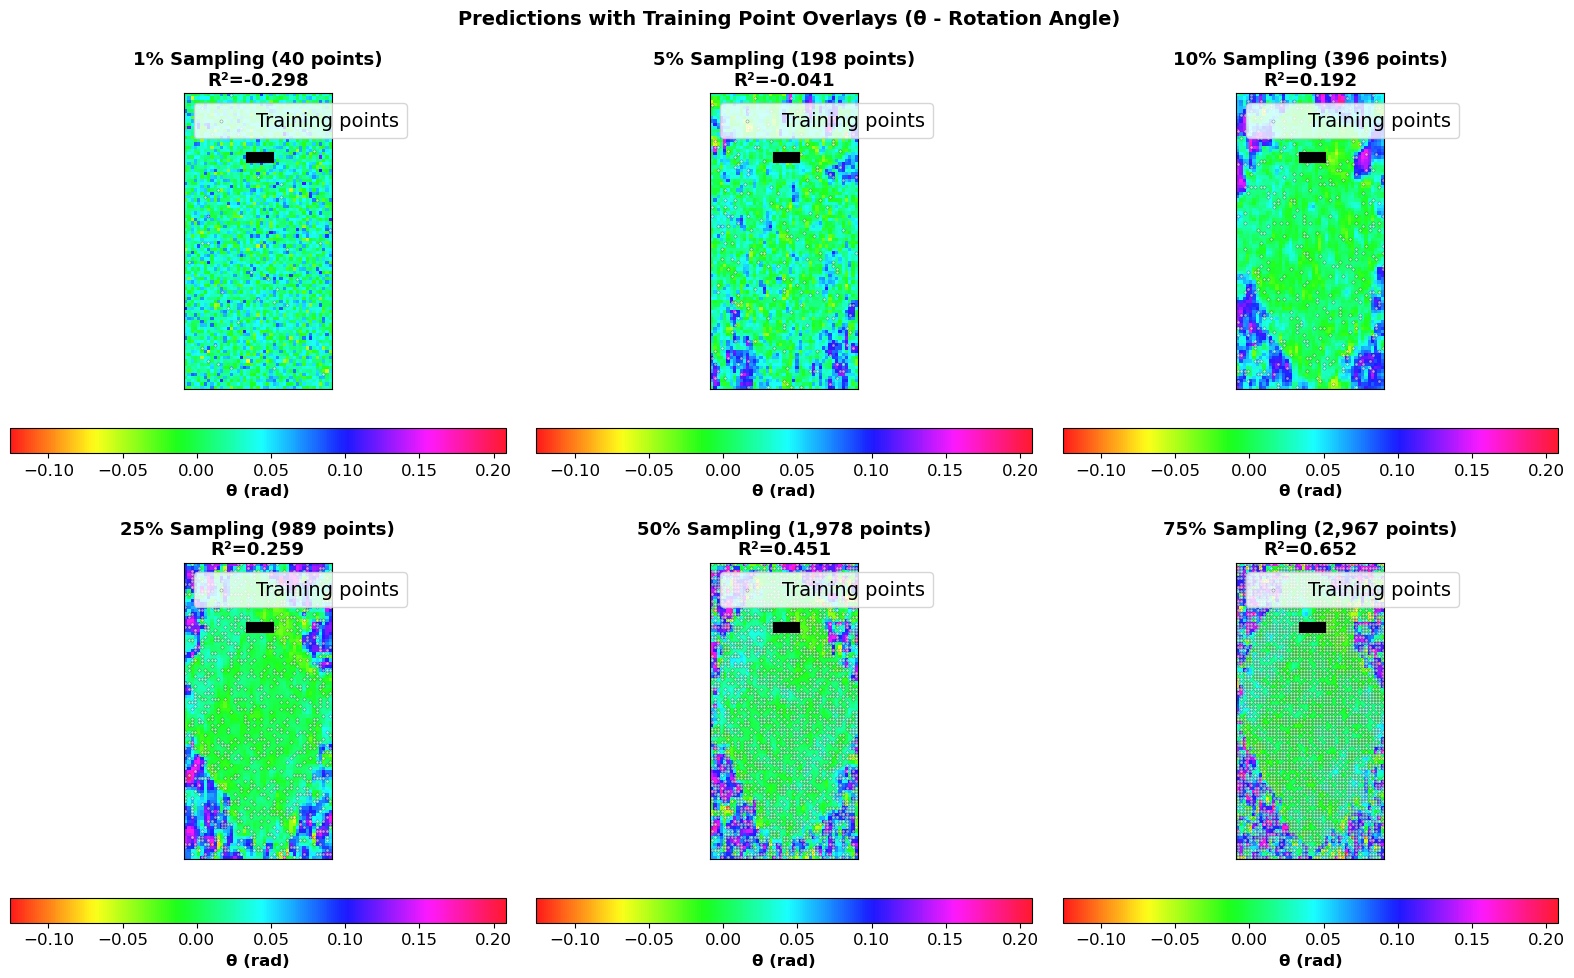

✓ Predictions with sampling overlay saved to: /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/07d_predictions_with_sampling_overlay_theta.png
  Calibration: 17.87 nm/pixel
  Colorbar range: -1.2588e-01 to 2.0801e-01 (consistent across all fractions)


In [16]:
# ============================================================================
# Overlay Sampling Points on Predictions (e_yy)
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Predictions with Training Point Overlays (e_yy)', fontsize=14, fontweight='bold')

selected_fracs = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75]

# Pixel-to-nm calibration
calibration_nm_per_pixel = 0.017872741 * 1000  # Convert µm to nm

# Compute consistent colorbar range across all fractions
all_preds_eyy = [all_predictions[frac]['e_yy'] for frac in selected_fracs]
valid_mask = mask > 0.5
all_valid_preds_eyy = np.concatenate([pred[valid_mask] for pred in all_preds_eyy])
vmin_global_eyy = np.nanmin(all_valid_preds_eyy)
vmax_global_eyy = np.nanmax(all_valid_preds_eyy)

for idx, frac in enumerate(selected_fracs):
    ax = axes.flat[idx]
    
    # Get predictions for this fraction
    e_yy_pred = all_predictions[frac]['e_yy']
    
    # Show prediction map with consistent colorbar range
    im = ax.imshow(e_yy_pred, cmap='RdBu', origin='lower', vmin=vmin_global_eyy, vmax=vmax_global_eyy, alpha=0.9)
    
    # Overlay training points as black dots
    sparse_mask_np = sparse_masks[frac].cpu().numpy().reshape(H, W)
    y_pts, x_pts = np.where(sparse_mask_np > 0.5)
    ax.scatter(x_pts, y_pts, c='black', s=5, alpha=0.5, edgecolors='white', linewidths=0.3, label='Training points')

    # Add colorbar with larger label fontsize
    cbar = plt.colorbar(im, ax=ax, label='e_yy', location='bottom', pad=0.1)
    cbar.set_label('e_yy', fontsize=12, fontweight='bold')
    
    n_train = int(sparse_mask_np.sum())
    ax.set_title(f'{frac*100:.0f}% Sampling ({n_train:,} points)\nR²={all_metrics[frac]["e_yy"]["R²"]:.3f}', 
                 fontweight='bold', fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='upper left', fontsize=14)
    
    # Add scale bar (in nm, no label)
    scale_length_px = W // 8  # 1/8 of width in pixels
    bar_x_start = W - scale_length_px - 20
    bar_x_end = W - 20
    bar_y = H - 20
    ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y], 'k-', linewidth=8)

plt.tight_layout()
plt.savefig(out_dir / "07b_predictions_with_sampling_overlay_eyy.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Predictions with sampling overlay saved to: {out_dir / '07b_predictions_with_sampling_overlay_eyy.png'}")
print(f"  Calibration: {calibration_nm_per_pixel:.2f} nm/pixel")
print(f"  Colorbar range: {vmin_global_eyy:.4e} to {vmax_global_eyy:.4e} (consistent across all fractions)")


# ============================================================================
# Overlay Sampling Points on Predictions (e_xy)
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Predictions with Training Point Overlays (e_xy)', fontsize=14, fontweight='bold')

# Compute consistent colorbar range across all fractions
all_preds_exy = [all_predictions[frac]['e_xy'] for frac in selected_fracs]
all_valid_preds_exy = np.concatenate([pred[valid_mask] for pred in all_preds_exy])
vmin_global_exy = np.nanmin(all_valid_preds_exy)
vmax_global_exy = np.nanmax(all_valid_preds_exy)

for idx, frac in enumerate(selected_fracs):
    ax = axes.flat[idx]
    
    # Get predictions for this fraction
    e_xy_pred = all_predictions[frac]['e_xy']
    
    # Show prediction map with consistent colorbar range
    im = ax.imshow(e_xy_pred, cmap='RdBu', origin='lower', vmin=vmin_global_exy, vmax=vmax_global_exy, alpha=0.9)
    
    # Overlay training points as black dots
    sparse_mask_np = sparse_masks[frac].cpu().numpy().reshape(H, W)
    y_pts, x_pts = np.where(sparse_mask_np > 0.5)
    ax.scatter(x_pts, y_pts, c='black', s=5, alpha=0.5, edgecolors='white', linewidths=0.3, label='Training points')

    # Add colorbar with larger label fontsize
    cbar = plt.colorbar(im, ax=ax, label='e_xy', location='bottom', pad=0.1)
    cbar.set_label('e_xy', fontsize=12, fontweight='bold')
    
    n_train = int(sparse_mask_np.sum())
    ax.set_title(f'{frac*100:.0f}% Sampling ({n_train:,} points)\nR²={all_metrics[frac]["e_xy"]["R²"]:.3f}', 
                 fontweight='bold', fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='upper left', fontsize=14)
    
    # Add scale bar (in nm, no label)
    scale_length_px = W // 8  # 1/8 of width in pixels
    bar_x_start = W - scale_length_px - 20
    bar_x_end = W - 20
    bar_y = H - 20
    ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y], 'k-', linewidth=8)

plt.tight_layout()
plt.savefig(out_dir / "07c_predictions_with_sampling_overlay_exy.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Predictions with sampling overlay saved to: {out_dir / '07c_predictions_with_sampling_overlay_exy.png'}")
print(f"  Calibration: {calibration_nm_per_pixel:.2f} nm/pixel")
print(f"  Colorbar range: {vmin_global_exy:.4e} to {vmax_global_exy:.4e} (consistent across all fractions)")


# ============================================================================
# Overlay Sampling Points on Predictions (theta - rotation angle)
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Predictions with Training Point Overlays (θ - Rotation Angle)', fontsize=14, fontweight='bold')

# Compute consistent colorbar range across all fractions
all_preds_theta = [all_predictions[frac]['theta'] for frac in selected_fracs]
all_valid_preds_theta = np.concatenate([pred[valid_mask] for pred in all_preds_theta])
vmin_global_theta = np.nanmin(all_valid_preds_theta)
vmax_global_theta = np.nanmax(all_valid_preds_theta)

for idx, frac in enumerate(selected_fracs):
    ax = axes.flat[idx]
    
    # Get predictions for this fraction
    theta_pred = all_predictions[frac]['theta']
    
    # Show prediction map with consistent colorbar range
    im = ax.imshow(theta_pred, cmap='hsv', origin='lower', vmin=vmin_global_theta, vmax=vmax_global_theta, alpha=0.9)
    
    # Overlay training points as black dots
    sparse_mask_np = sparse_masks[frac].cpu().numpy().reshape(H, W)
    y_pts, x_pts = np.where(sparse_mask_np > 0.5)
    ax.scatter(x_pts, y_pts, c='white', s=5, alpha=0.5, edgecolors='black', linewidths=0.3, label='Training points')

    # Add colorbar with larger label fontsize
    cbar = plt.colorbar(im, ax=ax, label='θ (rad)', location='bottom', pad=0.1)
    cbar.set_label('θ (rad)', fontsize=12, fontweight='bold')
    
    n_train = int(sparse_mask_np.sum())
    ax.set_title(f'{frac*100:.0f}% Sampling ({n_train:,} points)\nR²={all_metrics[frac]["theta"]["R²"]:.3f}', 
                 fontweight='bold', fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='upper left', fontsize=14)
    
    # Add scale bar (in nm, no label)
    scale_length_px = W // 8  # 1/8 of width in pixels
    bar_x_start = W - scale_length_px - 20
    bar_x_end = W - 20
    bar_y = H - 20
    ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y], 'k-', linewidth=8)

plt.tight_layout()
plt.savefig(out_dir / "07d_predictions_with_sampling_overlay_theta.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Predictions with sampling overlay saved to: {out_dir / '07d_predictions_with_sampling_overlay_theta.png'}")
print(f"  Calibration: {calibration_nm_per_pixel:.2f} nm/pixel")
print(f"  Colorbar range: {vmin_global_theta:.4e} to {vmax_global_theta:.4e} (consistent across all fractions)")

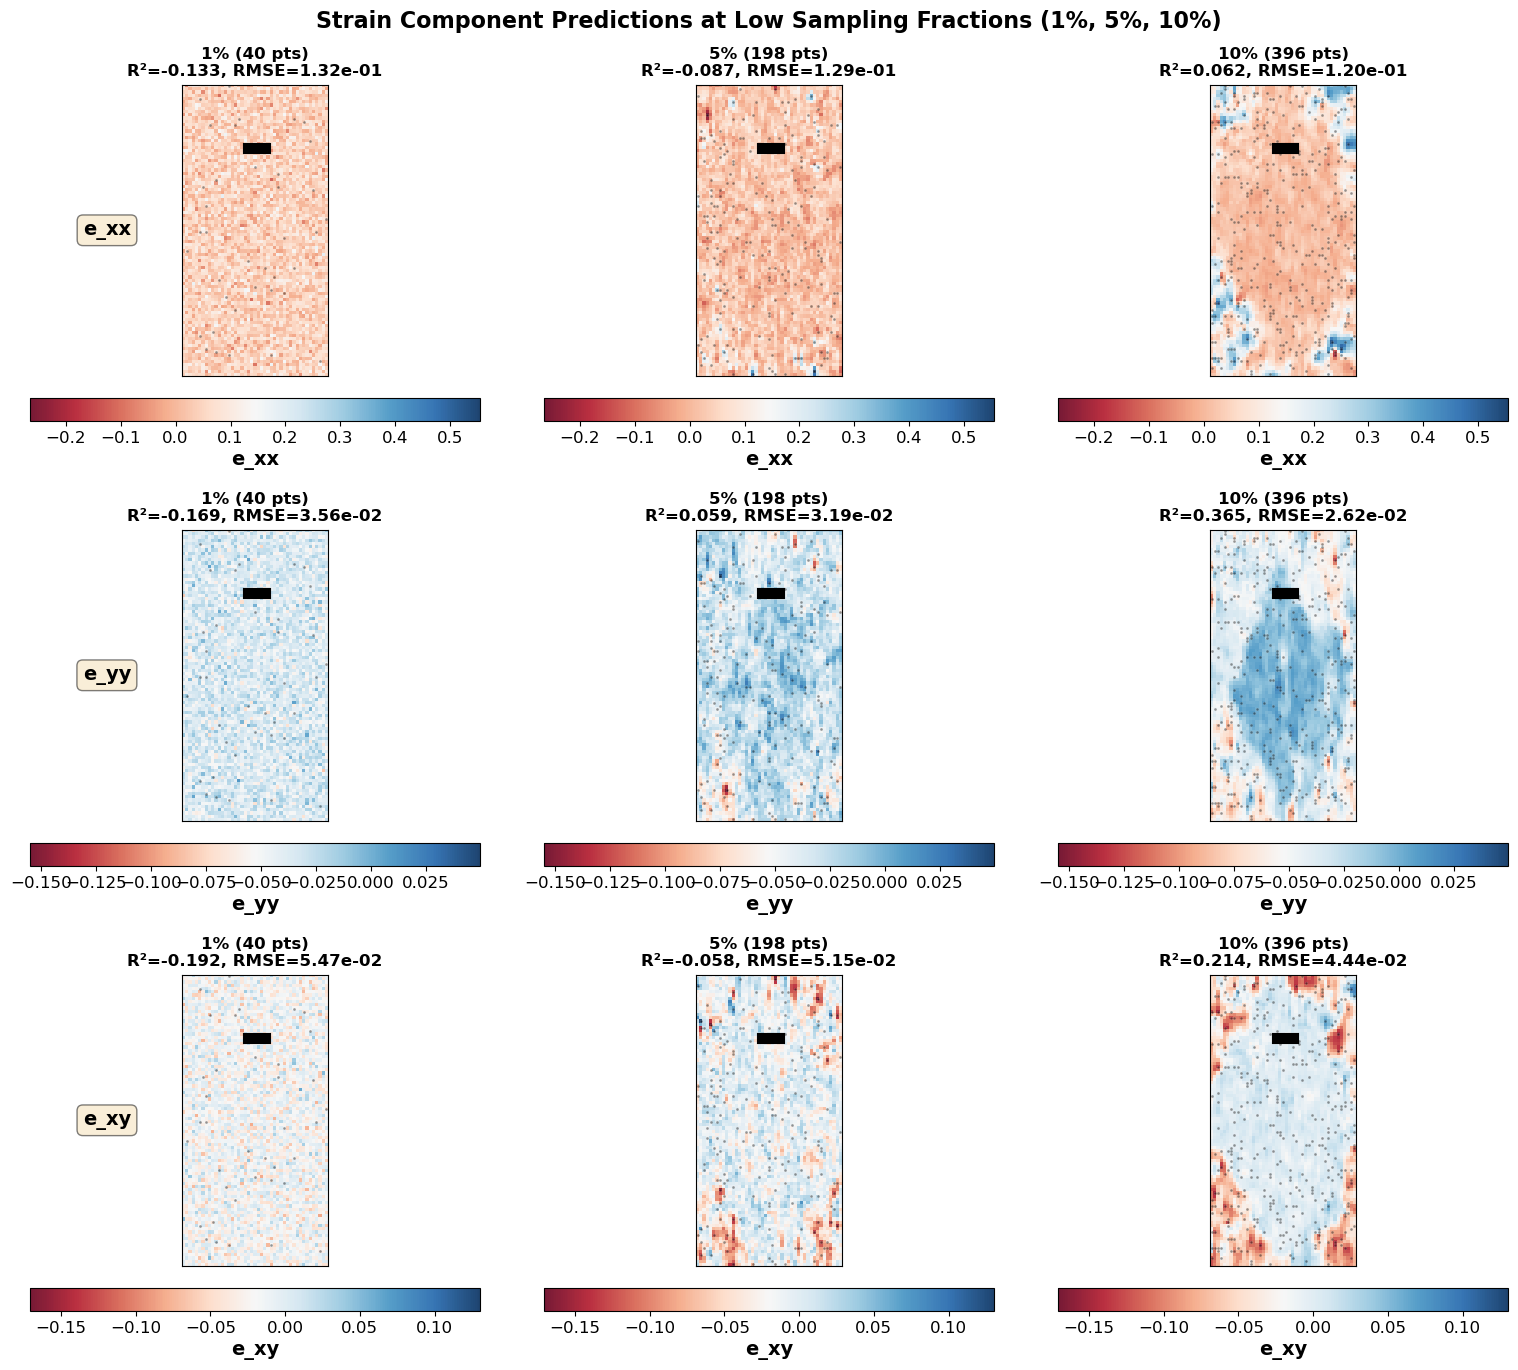

✓ Combined predictions (e_xx, e_yy, e_xy at 1%, 5%, 10%) saved
  Calibration: 17.87 nm/pixel

  Component ranges (consistent colorbars):
    e_xx  : -2.6554e-01 to 5.5441e-01
    e_yy  : -1.5507e-01 to 4.9589e-02
    e_xy  : -1.7083e-01 to 1.3043e-01


In [17]:
# ============================================================================
# Combined Predictions: e_xx, e_yy, e_xy at 1%, 5%, 10% Sampling
# ============================================================================

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Strain Component Predictions at Low Sampling Fractions (1%, 5%, 10%)', 
             fontsize=16, fontweight='bold')

selected_fracs = [0.01, 0.05, 0.10]
components = ['e_xx', 'e_yy', 'e_xy']

# Pixel-to-nm calibration
calibration_nm_per_pixel = 0.017872741 * 1000  # Convert µm to nm

# Compute consistent colorbars for each component across all fractions
component_ranges = {}
for comp in components:
    all_preds_comp = [all_predictions[frac][comp] for frac in selected_fracs]
    valid_mask = mask > 0.5
    all_valid_preds_comp = np.concatenate([pred[valid_mask] for pred in all_preds_comp])
    vmin_comp = np.nanmin(all_valid_preds_comp)
    vmax_comp = np.nanmax(all_valid_preds_comp)
    component_ranges[comp] = (vmin_comp, vmax_comp)

# Plot in grid: rows = components, columns = sampling fractions
for row, component in enumerate(components):
    vmin_c, vmax_c = component_ranges[component]
    
    for col, frac in enumerate(selected_fracs):
        ax = axes[row, col]
        
        # Get prediction
        pred = all_predictions[frac][component]
        
        # Show prediction map with consistent colorbar range for this component
        im = ax.imshow(pred, cmap='RdBu', origin='lower', vmin=vmin_c, vmax=vmax_c, alpha=0.9)
        
        # Overlay training points as black dots
        sparse_mask_np = sparse_masks[frac].cpu().numpy().reshape(H, W)
        y_pts, x_pts = np.where(sparse_mask_np > 0.5)
        ax.scatter(x_pts, y_pts, c='black', s=4, alpha=0.4, edgecolors='white', 
                  linewidths=0.2, label='Training points')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, location='bottom', pad=0.06, shrink=0.85)
        cbar.set_label(component, fontsize=14, fontweight='bold')
        cbar.ax.tick_params(labelsize=12)
        
        # Title with metrics
        n_train = int(sparse_mask_np.sum())
        r2 = all_metrics[frac][component]['R²']
        rmse = all_metrics[frac][component]['RMSE']
        
        if col == 0:
            # Add component label on left
            ax.text(-0.35, 0.5, component, transform=ax.transAxes, 
                   fontsize=14, fontweight='bold', va='center', ha='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_title(f'{frac*100:.0f}% ({n_train:,} pts)\nR²={r2:.3f}, RMSE={rmse:.2e}', 
                    fontweight='bold', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add scale bar (in nm, no label)
        scale_length_px = W // 8
        bar_x_start = W - scale_length_px - 20
        bar_x_end = W - 20
        bar_y = H - 20
        ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y], 'k-', linewidth=8)

plt.tight_layout()
plt.savefig(out_dir / "10_combined_predictions_1_5_10pct.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Combined predictions (e_xx, e_yy, e_xy at 1%, 5%, 10%) saved")
print(f"  Calibration: {calibration_nm_per_pixel:.2f} nm/pixel")
print(f"\n  Component ranges (consistent colorbars):")
for comp, (vmin, vmax) in component_ranges.items():
    print(f"    {comp:6s}: {vmin:.4e} to {vmax:.4e}")

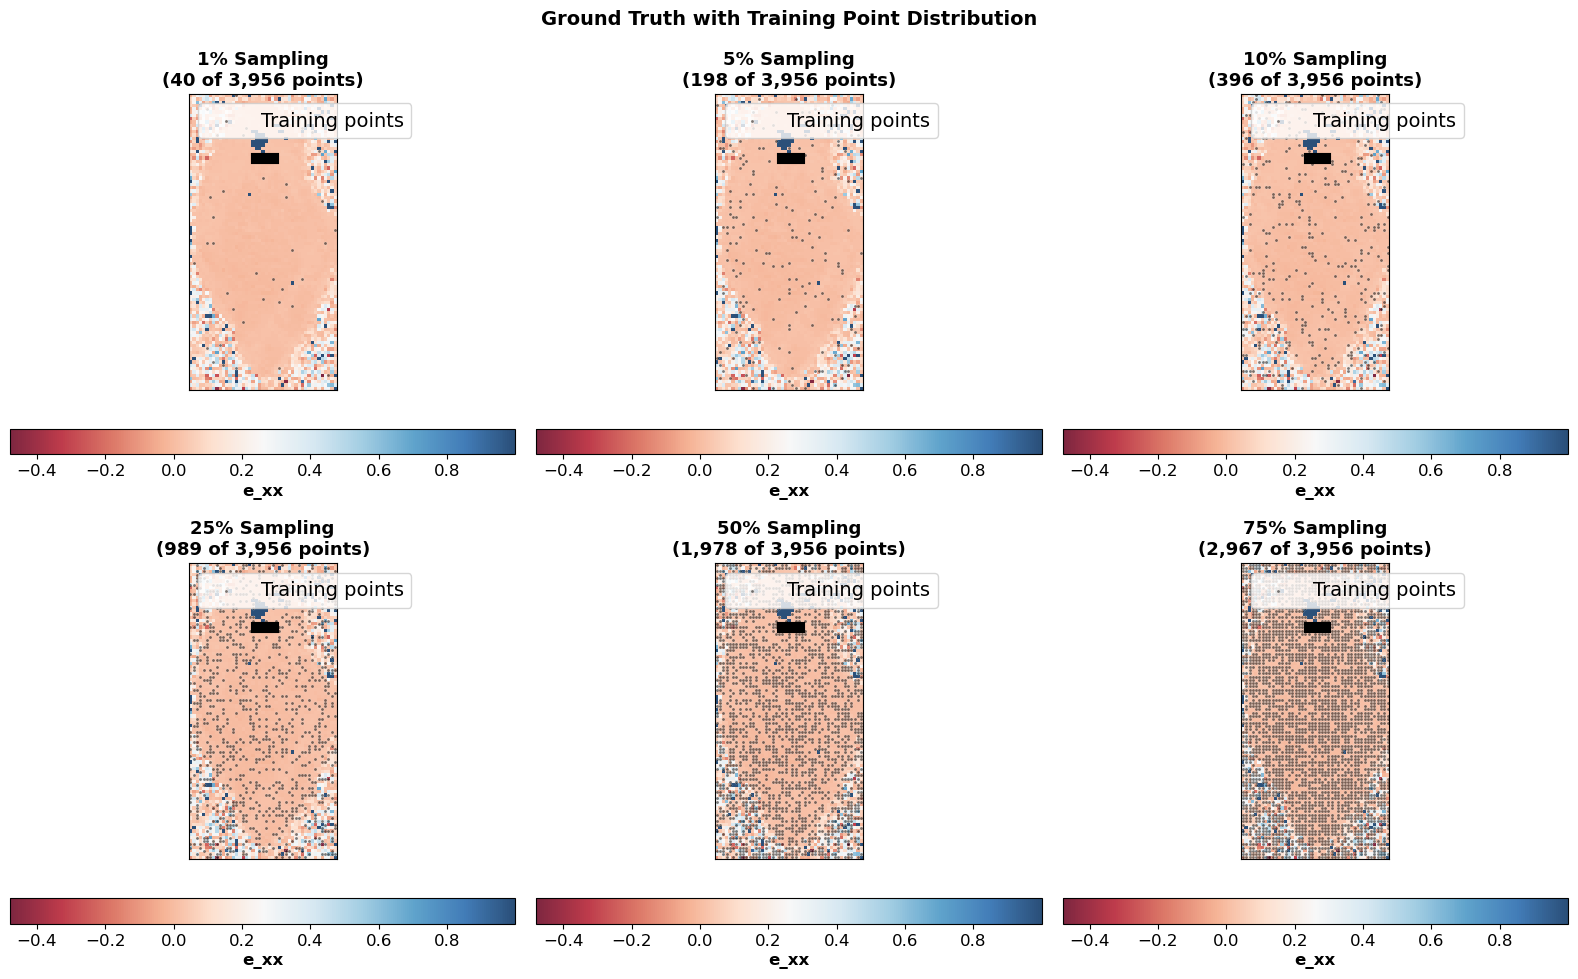

✓ Ground truth with sampling overlay saved to: /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/08_ground_truth_with_sampling_overlay.png
  Calibration: 17.87 nm/pixel


In [18]:
# Ground truth with sampling overlays
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Ground Truth with Training Point Distribution', fontsize=14, fontweight='bold')

# Pixel-to-nm calibration
calibration_nm_per_pixel = 0.017872741 * 1000  # Convert µm to nm

for idx, frac in enumerate([0.01, 0.05, 0.10, 0.25, 0.50, 0.75]):
    ax = axes.flat[idx]
    
    # Show ground truth with consistent colorbar
    valid_gt = e_xx[mask > 0.5]
    vmin, vmax = np.nanmin(valid_gt), np.nanmax(valid_gt)
    im = ax.imshow(e_xx, cmap='RdBu', origin='lower', vmin=vmin, vmax=vmax, alpha=0.85)
    
    # Overlay training points
    sparse_mask_np = sparse_masks[frac].cpu().numpy().reshape(H, W)
    y_pts, x_pts = np.where(sparse_mask_np > 0.5)
    ax.scatter(x_pts, y_pts, c='black', s=5, alpha=0.5, edgecolors='white', linewidths=0.3, label='Training points')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label='e_xx (ground truth)', location='bottom', pad=0.1)
    cbar.set_label('e_xx', fontsize=12, fontweight='bold')
    
    n_train = int(sparse_mask_np.sum())
    n_valid = int(mask.sum())
    ax.set_title(f'{frac*100:.0f}% Sampling\n({n_train:,} of {n_valid:,} points)', 
                 fontweight='bold', fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='upper left', fontsize=14)
    
    # Add scale bar at bottom right (in nm, no label)
    scale_length_px = W // 8  # 1/8 of width in pixels
    bar_x_start = W - scale_length_px - 20
    bar_x_end = W - 20
    bar_y = H - 20
    ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y], 'k-', linewidth=8)

plt.tight_layout()
plt.savefig(out_dir / "08_ground_truth_with_sampling_overlay.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Ground truth with sampling overlay saved to: {out_dir / '08_ground_truth_with_sampling_overlay.png'}")
print(f"  Calibration: {calibration_nm_per_pixel:.2f} nm/pixel")


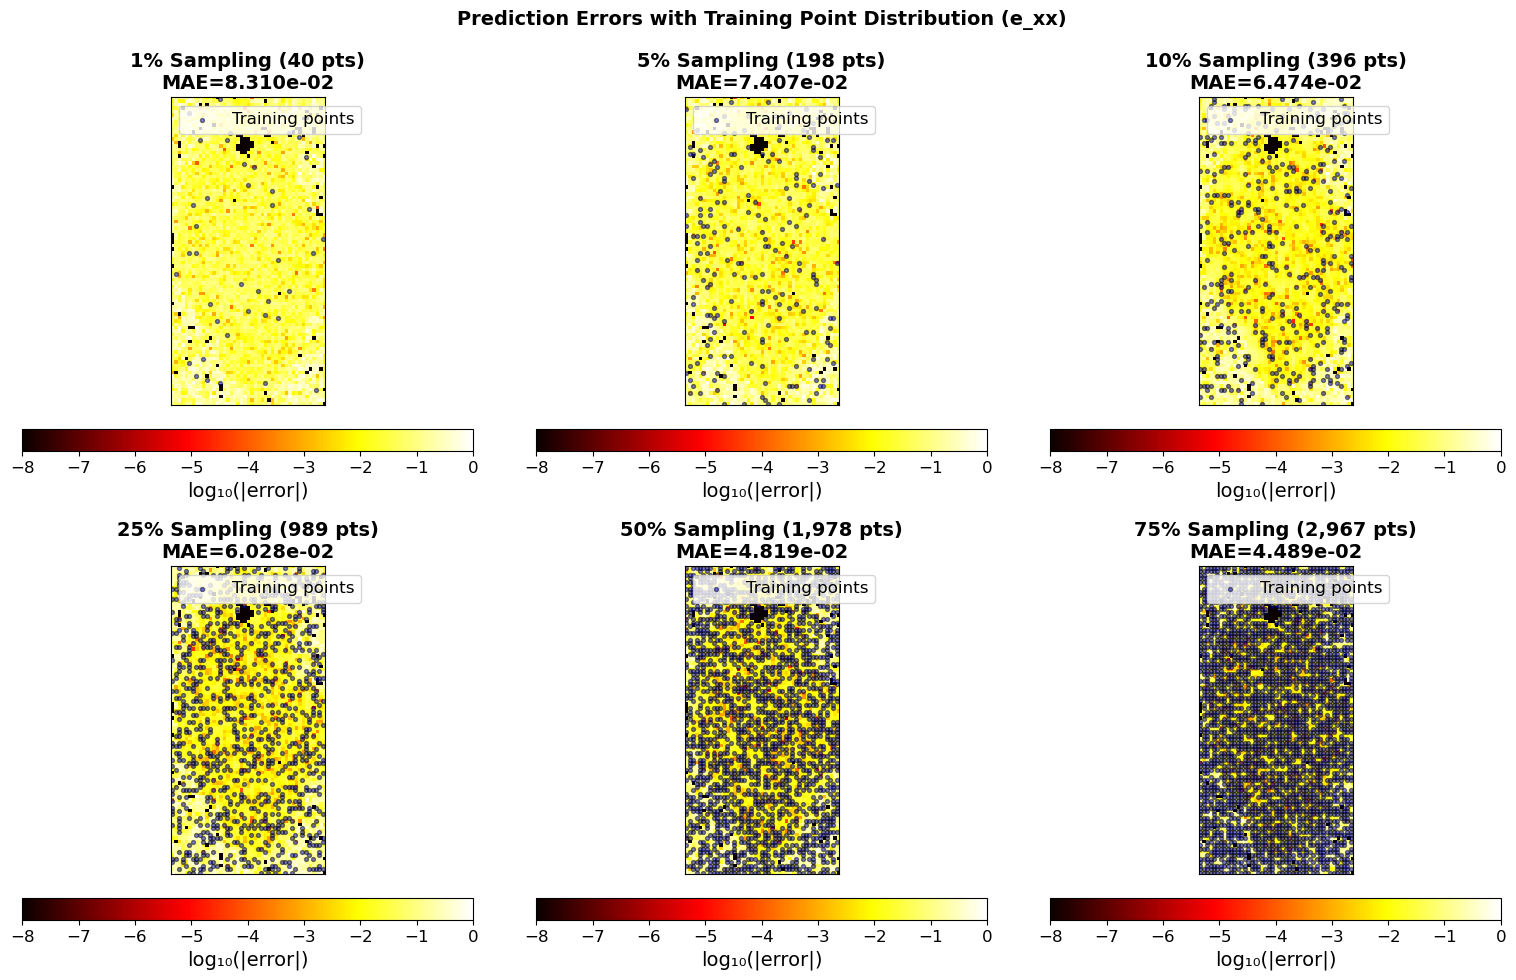

✓ Error maps with sampling overlay saved to: /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/09_error_maps_with_sampling_overlay.png


In [19]:
# Error maps with sampling overlays - showing where model struggles
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Prediction Errors with Training Point Distribution (e_xx)', fontsize=14, fontweight='bold')

for idx, frac in enumerate([0.01, 0.05, 0.10, 0.25, 0.50, 0.75]):
    ax = axes.flat[idx]
    
    # Compute absolute error
    e_xx_pred = all_predictions[frac]['e_xx']
    error_map = np.abs(e_xx_pred - e_xx)
    
    # Mask invalid regions
    error_display = np.copy(error_map)
    error_display[mask < 0.5] = 0.0
    
    # Use log scale for better visualization
    error_log = np.log10(error_display + 1e-10)
    vmin, vmax = -8, 0
    im = ax.imshow(error_log, cmap='hot', origin='lower', vmin=vmin, vmax=vmax)
    
    # Overlay training points
    sparse_mask_np = sparse_masks[frac].cpu().numpy().reshape(H, W)
    y_pts, x_pts = np.where(sparse_mask_np > 0.5)
    ax.scatter(x_pts, y_pts, c='blue', s=8, alpha=0.5, edgecolors='black', label='Training points')
    
    cbar = plt.colorbar(im, ax=ax, location='bottom', pad=0.06, shrink=0.85)
    cbar.set_label('log\u2081\u2080(|error|)', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    n_train = int(sparse_mask_np.sum())
    mae = all_metrics[frac]['e_xx']['MAE']
    ax.set_title(f'{frac*100:.0f}% Sampling ({n_train:,} pts)\nMAE={mae:.3e}', fontweight='bold', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig(out_dir / "09_error_maps_with_sampling_overlay.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Error maps with sampling overlay saved to: {out_dir / '09_error_maps_with_sampling_overlay.png'}")


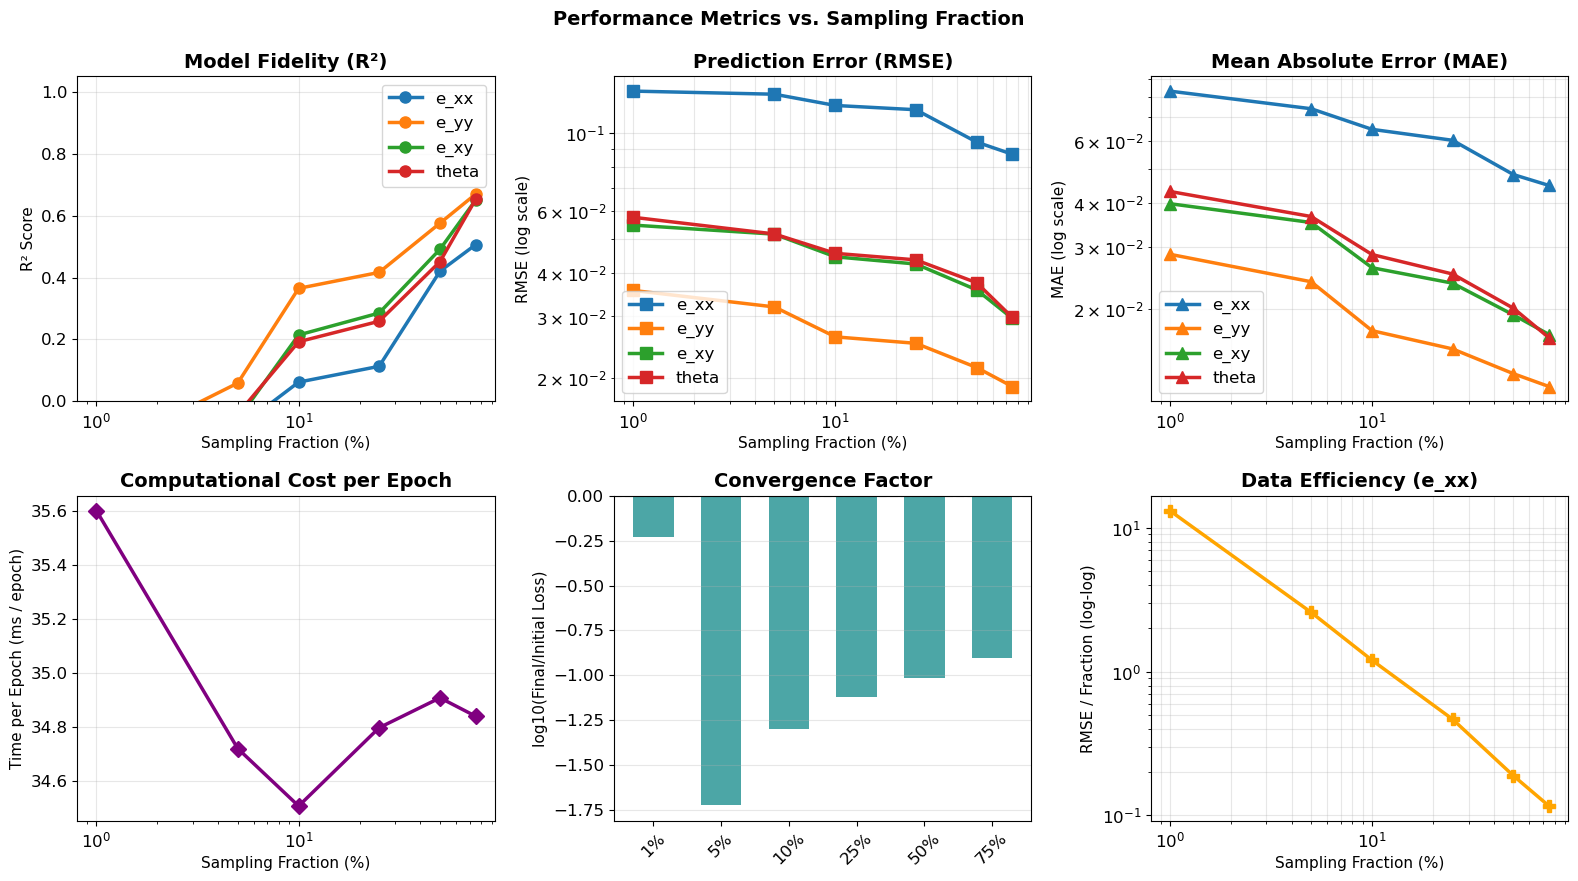

✓ Comprehensive metrics comparison saved


In [20]:
# 4. Metrics vs. Sampling Fraction (comprehensive comparison)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Performance Metrics vs. Sampling Fraction', fontsize=14, fontweight='bold')

fracs_pct = [f*100 for f in config["sampling_fractions"]]

# R² score
ax = axes[0, 0]
for component in ['e_xx', 'e_yy', 'e_xy', 'theta']:
    r2_values = [all_metrics[f][component]['R²'] for f in config["sampling_fractions"]]
    ax.plot(fracs_pct, r2_values, marker='o', linewidth=2.5, markersize=8, label=component)
ax.set_xscale('log')
ax.set_xlabel('Sampling Fraction (%)', fontsize=11)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('Model Fidelity (R²)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# RMSE
ax = axes[0, 1]
for component in ['e_xx', 'e_yy', 'e_xy', 'theta']:
    rmse_values = [all_metrics[f][component]['RMSE'] for f in config["sampling_fractions"]]
    ax.semilogy(fracs_pct, rmse_values, marker='s', linewidth=2.5, markersize=8, label=component)
ax.set_xscale('log')
ax.set_xlabel('Sampling Fraction (%)', fontsize=11)
ax.set_ylabel('RMSE (log scale)', fontsize=11)
ax.set_title('Prediction Error (RMSE)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# MAE
ax = axes[0, 2]
for component in ['e_xx', 'e_yy', 'e_xy', 'theta']:
    mae_values = [all_metrics[f][component]['MAE'] for f in config["sampling_fractions"]]
    ax.semilogy(fracs_pct, mae_values, marker='^', linewidth=2.5, markersize=8, label=component)
ax.set_xscale('log')
ax.set_xlabel('Sampling Fraction (%)', fontsize=11)
ax.set_ylabel('MAE (log scale)', fontsize=11)
ax.set_title('Mean Absolute Error (MAE)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# Training time – show ms/epoch (removes epoch-count artefact at 25% & 75%)
ax = axes[1, 0]
times       = [training_times[f]                      for f in config["sampling_fractions"]]
epochs_run  = [len(training_histories[f]['epoch'])    for f in config["sampling_fractions"]]
ms_per_ep   = [1000 * t / e for t, e in zip(times, epochs_run)]
ax.plot(fracs_pct, ms_per_ep, marker='D', linewidth=2.5, markersize=8, color='purple')
for xv, yv, ep in zip(fracs_pct, ms_per_ep, epochs_run):
    if ep >= config['epochs']:
        ax.annotate(f'{ep:,} ep', xy=(xv, yv), xytext=(0, 10),
                    textcoords='offset points', fontsize=9, ha='center', color='#c0392b')
ax.set_xscale('log')
ax.set_xlabel('Sampling Fraction (%)', fontsize=11)
ax.set_ylabel('Time per Epoch (ms / epoch)', fontsize=11)
ax.set_title('Computational Cost per Epoch', fontweight='bold')
ax.grid(True, alpha=0.3)

# Convergence speed (log10 of final loss / initial loss)
ax = axes[1, 1]
convergence = []
for f in config["sampling_fractions"]:
    hist = training_histories[f]
    conv = np.log10(hist['loss_total'][-1] / hist['loss_total'][0])
    convergence.append(conv)
ax.bar(range(len(fracs_pct)), convergence, color='teal', alpha=0.7, width=0.6)
ax.set_xticks(range(len(fracs_pct)))
ax.set_xticklabels([f'{f:.0f}%' for f in fracs_pct], rotation=45)
ax.set_ylabel('log10(Final/Initial Loss)', fontsize=11)
ax.set_title('Convergence Factor', fontweight='bold')
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# Data efficiency (RMSE gain per 1% additional data)
ax = axes[1, 2]
rmse_ref = all_metrics[config["sampling_fractions"][-1]]['e_xx']['RMSE']  # 100% reference (if available)
rmse_e_xx = [all_metrics[f]['e_xx']['RMSE'] for f in config["sampling_fractions"]]
efficiency = [rmse_e_xx[i] / (fracs_pct[i] / 100 + 1e-6) for i in range(len(fracs_pct))]
ax.loglog(fracs_pct, efficiency, marker='P', linewidth=2.5, markersize=8, color='orange')
ax.set_xlabel('Sampling Fraction (%)', fontsize=11)
ax.set_ylabel('RMSE / Fraction (log-log)', fontsize=11)
ax.set_title('Data Efficiency (e_xx)', fontweight='bold')
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(out_dir / "05_metrics_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Comprehensive metrics comparison saved")

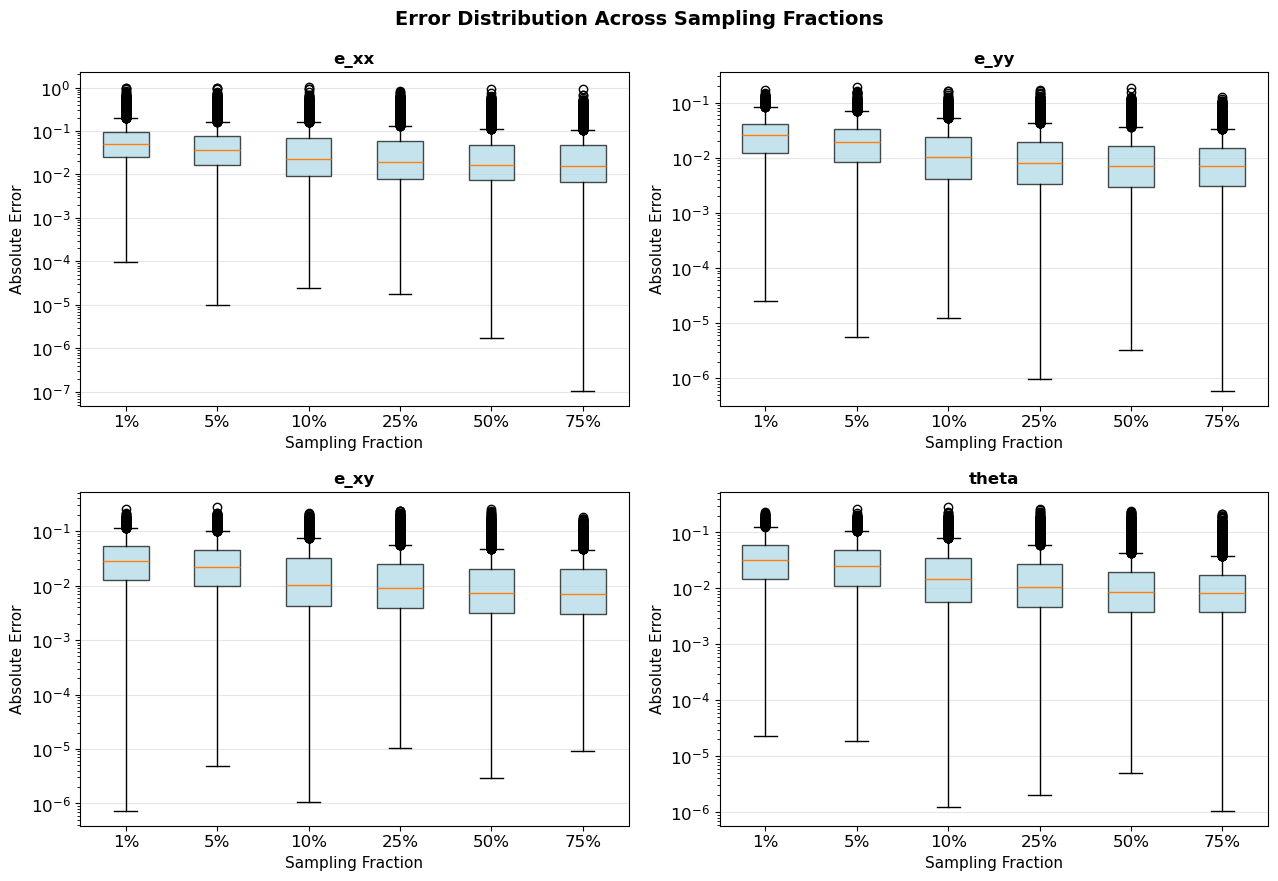

✓ Error distributions saved


In [21]:
# 5. Box plots of errors across all fractions
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Error Distribution Across Sampling Fractions', fontsize=14, fontweight='bold')

for idx, component in enumerate(['e_xx', 'e_yy', 'e_xy', 'theta']):
    ax = axes.flat[idx]
    
    error_data = []
    labels_plot = []
    for frac in config["sampling_fractions"]:
        pred = all_predictions[frac][component]
        true = [e_xx, e_yy, e_xy, theta][idx]
        errors = np.abs(pred[mask > 0.5] - true[mask > 0.5])
        error_data.append(errors)
        labels_plot.append(f'{frac*100:.0f}%')
    
    try:                                 # matplotlib >= 3.9 renamed labels -> tick_labels
        bp = ax.boxplot(error_data, tick_labels=labels_plot, patch_artist=True)
    except TypeError:
        bp = ax.boxplot(error_data, labels=labels_plot, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    ax.set_ylabel('Absolute Error', fontsize=11)
    ax.set_xlabel('Sampling Fraction', fontsize=11)
    ax.set_title(f'{component}', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig(out_dir / "06_error_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Error distributions saved")

In [22]:
# 6. Comprehensive summary table
print("\n" + "="*70)
print("FINAL RESULTS: Comprehensive Performance Summary")
print("="*70)

summary_rows = []
for frac in config["sampling_fractions"]:
    row = {
        'Sampling %': f'{frac*100:.1f}%',
        'Train Points': int((sparse_masks[frac].sum()).item()),
        '% of Grid': f'{100*int((sparse_masks[frac].sum()).item())/(H*W):.1f}%',
        'R² (e_xx)': f'{all_metrics[frac]["e_xx"]["R²"]:.4f}',
        'RMSE (e_xx)': f'{all_metrics[frac]["e_xx"]["RMSE"]:.4e}',
        'R² (avg)': f'{np.mean([all_metrics[frac][c]["R²"] for c in ["e_xx", "e_yy", "e_xy", "theta"]]):.4f}',
        'Time (s)': f'{training_times[frac]:.1f}',
        'Epochs': len(training_histories[frac]['epoch']),
    }
    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows)
print(summary_table.to_string(index=False))

# Save summary to CSV
csv_out = out_dir / "results_summary.csv"
summary_table.to_csv(csv_out, index=False)
print(f"\n✓ Summary saved to: {csv_out}")

# Save detailed metrics to CSV
detailed_metrics_list = []
for frac in config["sampling_fractions"]:
    for component in ['e_xx', 'e_yy', 'e_xy', 'theta']:
        for metric_name, metric_val in all_metrics[frac][component].items():
            detailed_metrics_list.append({
                'Sampling %': frac * 100,
                'Component': component,
                'Metric': metric_name,
                'Value': metric_val,
            })

detailed_df = pd.DataFrame(detailed_metrics_list)
detailed_csv = out_dir / "detailed_metrics.csv"
detailed_df.to_csv(detailed_csv, index=False)
print(f"✓ Detailed metrics saved to: {detailed_csv}")

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

# Best performance
best_r2_frac = max(config["sampling_fractions"], key=lambda f: all_metrics[f]['e_xx']['R²'])
print(f"  ✓ Best e_xx R² achieved at: {best_r2_frac*100:.1f}% sampling (R²={all_metrics[best_r2_frac]['e_xx']['R²']:.4f})")

# Data efficiency sweet spot
print(f"  ✓ Recommendation for high accuracy (~0.90 R²):")
for frac in config["sampling_fractions"]:
    if all_metrics[frac]['e_xx']['R²'] > 0.90:
        print(f"      Use ≥{frac*100:.0f}% data (RMSE={all_metrics[frac]['e_xx']['RMSE']:.4e})")
        break

print(f"  ✓ Computational efficiency: Training times range from {min(training_times.values()):.1f}s to {max(training_times.values()):.1f}s")
print(f"  ✓ Total training time: {total_time:.1f}s")
print("\n" + "="*70)


FINAL RESULTS: Comprehensive Performance Summary
Sampling %  Train Points % of Grid R² (e_xx) RMSE (e_xx) R² (avg) Time (s)  Epochs
      1.0%            40      1.0%   -0.1328  1.3191e-01  -0.1979     22.0     618
      5.0%           198      4.9%   -0.0874  1.2924e-01  -0.0320     16.4     471
     10.0%           396      9.8%    0.0620  1.2003e-01   0.2084     25.8     749
     25.0%           989     24.4%    0.1131  1.1672e-01   0.2684     26.1     751
     50.0%          1978     48.8%    0.4205  9.4348e-02   0.4847     36.0    1030
     75.0%          2967     73.3%    0.5060  8.7104e-02   0.6195     33.9     973

✓ Summary saved to: /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/results_summary.csv
✓ Detailed metrics saved to: /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/detailed_metrics.csv

KEY INSIGHTS
  ✓ Best e_xx R² achieved at: 75.0% sampling (R²=0.5060)
  ✓ Recommendation for high accuracy (~0.

In [23]:
# ============================================================================
# SECTION 8b: Physics-consistency diagnostics (physical units)
#   R_equil  [GPa/um]   elastic-equilibrium residual
#   R_compat [1/um^2]   Saint-Venant compatibility residual
# Evaluated on the dense reconstructed grid with central finite differences.
# ============================================================================

physics_diag = {}
print("\n" + "="*70)
print("PHYSICS-CONSISTENCY DIAGNOSTICS (PINN reconstructions)")
print("="*70)
print(f"{'frac':>6} | {'R_equil [GPa/um]':>18} | {'R_compat [1/um^2]':>18}")
print("-"*52)
for frac in config["sampling_fractions"]:
    p = all_predictions[frac]
    R_eq, R_co = grid_physics_diagnostics(p["e_xx"], p["e_yy"], p["e_xy"], mask, config)
    physics_diag[frac] = {"R_equil": R_eq, "R_compat": R_co}
    print(f"{frac*100:5.0f}% | {R_eq:18.4e} | {R_co:18.4e}")

pd.DataFrame([
    {"Sampling %": f"{f*100:.0f}%", "R_equil (GPa/um)": physics_diag[f]["R_equil"],
     "R_compat (1/um^2)": physics_diag[f]["R_compat"]}
    for f in config["sampling_fractions"]
]).to_csv(out_dir / "physics_diagnostics.csv", index=False)
print(f"\n✓ Saved {out_dir / 'physics_diagnostics.csv'}")



PHYSICS-CONSISTENCY DIAGNOSTICS (PINN reconstructions)
  frac |   R_equil [GPa/um] |  R_compat [1/um^2]
----------------------------------------------------
    1% |         2.5751e+02 |         1.0743e+02
    5% |         2.8904e+02 |         1.0649e+02
   10% |         2.9533e+02 |         8.2025e+01
   25% |         4.1625e+02 |         1.1006e+02
   50% |         4.1843e+02 |         1.1612e+02
   75% |         3.7881e+02 |         1.0868e+02

✓ Saved /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/physics_diagnostics.csv


In [24]:
# ============================================================================
# SECTION 8c: Ablation -- data-only SIREN (lambda_phys = 0)
# Identical architecture, schedule and data; physics weight set to zero.
# Isolates the value of the PDE prior from network capacity.
# ============================================================================

ablation_models      = {}
ablation_predictions = {}
ablation_metrics     = {}
ablation_diag        = {}

print("\n" + "="*70)
print("ABLATION: data-only SIREN baseline (lambda_phys = 0)")
print("="*70)
for frac in config["sampling_fractions"]:
    print(f"\n▶ Ablation on {frac*100:.0f}% data ...")
    m0, _ = train_pinn_sparse(frac, sparse_masks[frac], config, device, lambda_phys_scale=0.0)
    preds0, mets0 = evaluate_model(m0, x_flat, y_flat, e_xx, e_yy, e_xy, theta,
                                   mask, H, W, device)
    R_eq0, R_co0 = grid_physics_diagnostics(preds0["e_xx"], preds0["e_yy"], preds0["e_xy"],
                                            mask, config)
    ablation_models[frac]      = m0
    ablation_predictions[frac] = preds0
    ablation_metrics[frac]     = mets0
    ablation_diag[frac]        = {"R_equil": R_eq0, "R_compat": R_co0}

# Comparison table: physics residual reduction and MAE change vs data-only SIREN
print("\n" + "="*78)
print("PINN vs data-only SIREN  (equal data, equal capacity, equal schedule)")
print("="*78)
print(f"{'frac':>6} | {'R_equil x':>10} | {'R_compat x':>11} | "
      f"{'MAE PINN':>10} | {'MAE SIREN':>10} | {'MAE redux':>9}")
print("-"*78)
ablation_rows = []
for frac in config["sampling_fractions"]:
    re_pinn = physics_diag[frac]["R_equil"];  re_abl = ablation_diag[frac]["R_equil"]
    rc_pinn = physics_diag[frac]["R_compat"]; rc_abl = ablation_diag[frac]["R_compat"]
    mae_pinn = all_metrics[frac]["e_xx"]["MAE"]
    mae_abl  = ablation_metrics[frac]["e_xx"]["MAE"]
    eq_ratio = re_abl / re_pinn if re_pinn > 0 else float("nan")
    co_ratio = rc_abl / rc_pinn if rc_pinn > 0 else float("nan")
    mae_redux = 100.0 * (mae_abl - mae_pinn) / mae_abl if mae_abl > 0 else float("nan")
    print(f"{frac*100:5.0f}% | {eq_ratio:10.2f} | {co_ratio:11.2f} | "
          f"{mae_pinn:10.4e} | {mae_abl:10.4e} | {mae_redux:8.1f}%")
    ablation_rows.append({
        "Sampling %": f"{frac*100:.0f}%",
        "R_equil PINN": re_pinn, "R_equil SIREN-only": re_abl, "R_equil ratio": eq_ratio,
        "R_compat PINN": rc_pinn, "R_compat SIREN-only": rc_abl, "R_compat ratio": co_ratio,
        "MAE PINN (e_xx)": mae_pinn, "MAE SIREN-only (e_xx)": mae_abl,
        "MAE reduction %": mae_redux,
    })

pd.DataFrame(ablation_rows).to_csv(out_dir / "ablation_summary.csv", index=False)
eq_ratios = [r["R_equil ratio"] for r in ablation_rows]
co_ratios = [r["R_compat ratio"] for r in ablation_rows]
print(f"\nEquilibrium-residual reduction: {min(eq_ratios):.1f}x - {max(eq_ratios):.1f}x")
print(f"Compatibility-residual reduction: {min(co_ratios):.1f}x - {max(co_ratios):.1f}x")
print(f"✓ Saved {out_dir / 'ablation_summary.csv'}")



ABLATION: data-only SIREN baseline (lambda_phys = 0)

▶ Ablation on 1% data ...


Train 1% [data-only]:   0%|          | 0/5000 [00:00<?, ?it/s]

Train 1% [data-only]:   0%|          | 15/5000 [00:00<00:35, 140.44it/s]

Train 1% [data-only]:   1%|          | 30/5000 [00:00<00:34, 144.03it/s]

Train 1% [data-only]:   1%|          | 45/5000 [00:00<00:33, 146.09it/s]

...

Train 75% [data-only]:  18%|█▊        | 915/5000 [00:06<00:27, 148.25it/s]

Train 75% [data-only]:  19%|█▊        | 930/5000 [00:06<00:27, 148.08it/s]

Train 75% [data-only]:  19%|█▉        | 945/5000 [00:06<00:27, 148.12it/s]

Train 75% [data-only]:  19%|█▉        | 960/5000 [00:06<00:27, 148.00it/s]

      -> early stop @ epoch 969 (best val loss 8.2430e-01)

PINN vs data-only SIREN  (equal data, equal capacity, equal schedule)
  frac |  R_equil x |  R_compat x |   MAE PINN |  MAE SIREN | MAE redux
------------------------------------------------------------------------------
    1% |       1.69 |        1.66 | 8.3098e-02 | 9.4772e-02 |     12.3%
    5% |       1.07 |        1.53 | 7.4068e-02 | 8.2925e-02 |     10.7%
   10% |       1.55 |        1.76 | 6.4740e-02 | 8.3098e-02 |     22.1%
   25% |       1.31 |        1.60 | 6.0278e-02 | 6.5126e-02 |      7.4%
   50% |       1.42 |        1.72 | 4.8187e-02 | 4.1481e-02 |    -16.2%
   75% |       1.64 |        2.04 | 4.4888e-02 | 3.0374e-02 |    -47.8%

Equilibrium-residual reduction: 1.1x - 1.7x
Compatibility-residual reduction: 1.5x - 2.0x
✓ Saved /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/ablation_summary.csv


In [25]:
# ============================================================================
# SECTION 8d: Classical sparse-reconstruction baselines
#   CS : compressed sensing, L1 in a Daubechies wavelet basis solved by ISTA
#   GP : Gaussian-process regression with a Matern-3/2 kernel
# Both are evaluated on the same sampling masks as the PINN. The data-only SIREN
# (Section 8c ablation) is the third baseline. Equilibrium / compatibility
# residuals use the SAME finite-difference operator as the PINN diagnostics.
# ============================================================================
import pywt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel

def cs_reconstruct(channel_map, samp_mask_2d, n_iter=300, lam=None, wavelet="db4"):
    """Scattered-sample -> full image via ISTA with soft-thresholding in a 2D
    wavelet basis. M is a pixel-selection operator so ||M^T M|| = 1 (step = 1)."""
    M = samp_mask_2d > 0.5
    y = np.where(M, channel_map, 0.0).astype(np.float64)
    x = np.full_like(y, channel_map[M].mean())
    level = pywt.dwtn_max_level(channel_map.shape, wavelet)
    level = max(1, min(level, 4))
    coeffs0 = pywt.wavedec2(y, wavelet, level=level)
    arr0, slices = pywt.coeffs_to_array(coeffs0)
    if lam is None:
        lam = 0.02 * np.abs(arr0).max()
    for _ in range(n_iter):
        x[M] = channel_map[M]                          # enforce data consistency
        arr, sl = pywt.coeffs_to_array(pywt.wavedec2(x, wavelet, level=level))
        arr = np.sign(arr) * np.maximum(np.abs(arr) - lam, 0.0)  # soft threshold
        x = pywt.waverec2(pywt.array_to_coeffs(arr, sl, output_format="wavedec2"),
                          wavelet)[:channel_map.shape[0], :channel_map.shape[1]]
    x[M] = channel_map[M]
    return x

def gp_reconstruct(channel_map, samp_flat_idx, n_cap=1500):
    """GP regression (Matern-3/2) over normalised coordinates; train points
    capped at n_cap for tractability, prediction over the full grid in batches."""
    xs = x_flat.cpu().numpy(); ys = y_flat.cpu().numpy()
    vals = channel_map.flatten()
    idx = np.asarray(samp_flat_idx)
    if len(idx) > n_cap:
        idx = np.random.RandomState(SEED).choice(idx, n_cap, replace=False)
    Xtr = np.stack([xs[idx], ys[idx]], axis=1); ytr = vals[idx]
    ymu = ytr.mean()
    kernel = (ConstantKernel(1.0) * Matern(length_scale=0.1, nu=1.5)
              + WhiteKernel(noise_level=1e-3))
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=False, alpha=1e-6)
    gp.fit(Xtr, ytr - ymu)
    Xall = np.stack([xs, ys], axis=1)
    pred = np.empty(Xall.shape[0])
    for s in range(0, Xall.shape[0], 8000):
        pred[s:s+8000] = gp.predict(Xall[s:s+8000])
    return (pred + ymu).reshape(channel_map.shape)

def _metrics(pred, true, m):
    pv, tv = pred[m], true[m]
    rmse = float(np.sqrt(np.mean((pv - tv) ** 2)))
    mae  = float(np.mean(np.abs(pv - tv)))
    ss_res = np.sum((tv - pv) ** 2); ss_tot = np.sum((tv - tv.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
    return rmse, mae, r2

m_valid = mask > 0.5
baseline_rows = []
baseline_store = {}
print("\n" + "="*70)
print("BASELINES: compressed sensing (CS) and Gaussian process (GP)")
print("="*70)
for frac in config["sampling_fractions"]:
    sp2d = sparse_masks[frac].cpu().numpy().reshape(H, W)
    sidx = sampled_indices[frac]
    chans = {}
    for nm, cmap in [("e_xx", e_xx), ("e_yy", e_yy), ("e_xy", e_xy)]:
        chans[nm] = {
            "cs": cs_reconstruct(cmap, sp2d),
            "gp": gp_reconstruct(cmap, sidx),
        }
    baseline_store[frac] = chans
    for method in ["cs", "gp"]:
        rmse, mae, r2 = _metrics(chans["e_xx"][method], e_xx, m_valid)
        R_eq, R_co = grid_physics_diagnostics(
            chans["e_xx"][method], chans["e_yy"][method], chans["e_xy"][method], mask, config)
        baseline_rows.append({
            "Sampling %": f"{frac*100:.0f}%", "method": method.upper(),
            "RMSE (e_xx)": rmse, "MAE (e_xx)": mae, "R2 (e_xx)": r2,
            "R_equil (GPa/um)": R_eq, "R_compat (1/um^2)": R_co})
    # SIREN-only (ablation) row for the same fraction
    rmse, mae, r2 = (ablation_metrics[frac]["e_xx"]["RMSE"],
                     ablation_metrics[frac]["e_xx"]["MAE"],
                     ablation_metrics[frac]["e_xx"]["R²"])
    baseline_rows.append({
        "Sampling %": f"{frac*100:.0f}%", "method": "SIREN-only",
        "RMSE (e_xx)": rmse, "MAE (e_xx)": mae, "R2 (e_xx)": r2,
        "R_equil (GPa/um)": ablation_diag[frac]["R_equil"],
        "R_compat (1/um^2)": ablation_diag[frac]["R_compat"]})
    # PINN row
    baseline_rows.append({
        "Sampling %": f"{frac*100:.0f}%", "method": "PINN",
        "RMSE (e_xx)": all_metrics[frac]["e_xx"]["RMSE"],
        "MAE (e_xx)": all_metrics[frac]["e_xx"]["MAE"],
        "R2 (e_xx)": all_metrics[frac]["e_xx"]["R²"],
        "R_equil (GPa/um)": physics_diag[frac]["R_equil"],
        "R_compat (1/um^2)": physics_diag[frac]["R_compat"]})
    print(f"  {frac*100:5.0f}% done")

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(out_dir / "baselines_summary.csv", index=False)
print(f"\n✓ Saved {out_dir / 'baselines_summary.csv'}")

# Headline comparison at 10% sampling (MAE on e_xx, relative to PINN)
f10 = 0.10
sub = baseline_df[baseline_df["Sampling %"] == "10%"].set_index("method")
mae_pinn = sub.loc["PINN", "MAE (e_xx)"]
print(f"\nAt 10% sampling -- MAE(e_xx) reduction of PINN vs baseline:")
for meth in ["CS", "GP", "SIREN-only"]:
    mae_b = sub.loc[meth, "MAE (e_xx)"]
    print(f"  vs {meth:11s}: {100*(mae_b-mae_pinn)/mae_b:5.1f}%   "
          f"(R_equil ratio {sub.loc[meth,'R_equil (GPa/um)']/sub.loc['PINN','R_equil (GPa/um)']:.1f}x)")



BASELINES: compressed sensing (CS) and Gaussian process (GP)


/opt/anaconda3/envs/pinns/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/pinns/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/pinns/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/pinns/lib/pyt

      1% done


/opt/anaconda3/envs/pinns/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/pinns/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


      5% done


     10% done


     25% done


     50% done


     75% done

✓ Saved /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/baselines_summary.csv

At 10% sampling -- MAE(e_xx) reduction of PINN vs baseline:
  vs CS         :  -0.8%   (R_equil ratio 1.4x)
  vs GP         :  -5.3%   (R_equil ratio 0.2x)
  vs SIREN-only :  22.1%   (R_equil ratio 1.5x)


Training MC-Dropout PINN at 10% sampling ...


StrainPINN_MCDropout:   0%|          | 0/3000 [00:00<?, ?it/s]

StrainPINN_MCDropout:   0%|          | 1/3000 [00:00<10:13,  4.89it/s]

StrainPINN_MCDropout:   0%|          | 4/3000 [00:00<03:38, 13.71it/s]

StrainPINN_MCDropout:   0%|          | 7/3000 [00:00<02:47, 17.89it/s]

...

StrainPINN_MFVI: 100%|█████████▉| 2995/3000 [03:07<00:00, 15.92it/s]

StrainPINN_MFVI: 100%|█████████▉| 2997/3000 [03:07<00:00, 15.91it/s]

StrainPINN_MFVI: 100%|█████████▉| 2999/3000 [03:07<00:00, 15.94it/s]

Running stochastic inference ...


Uncertainty maps computed


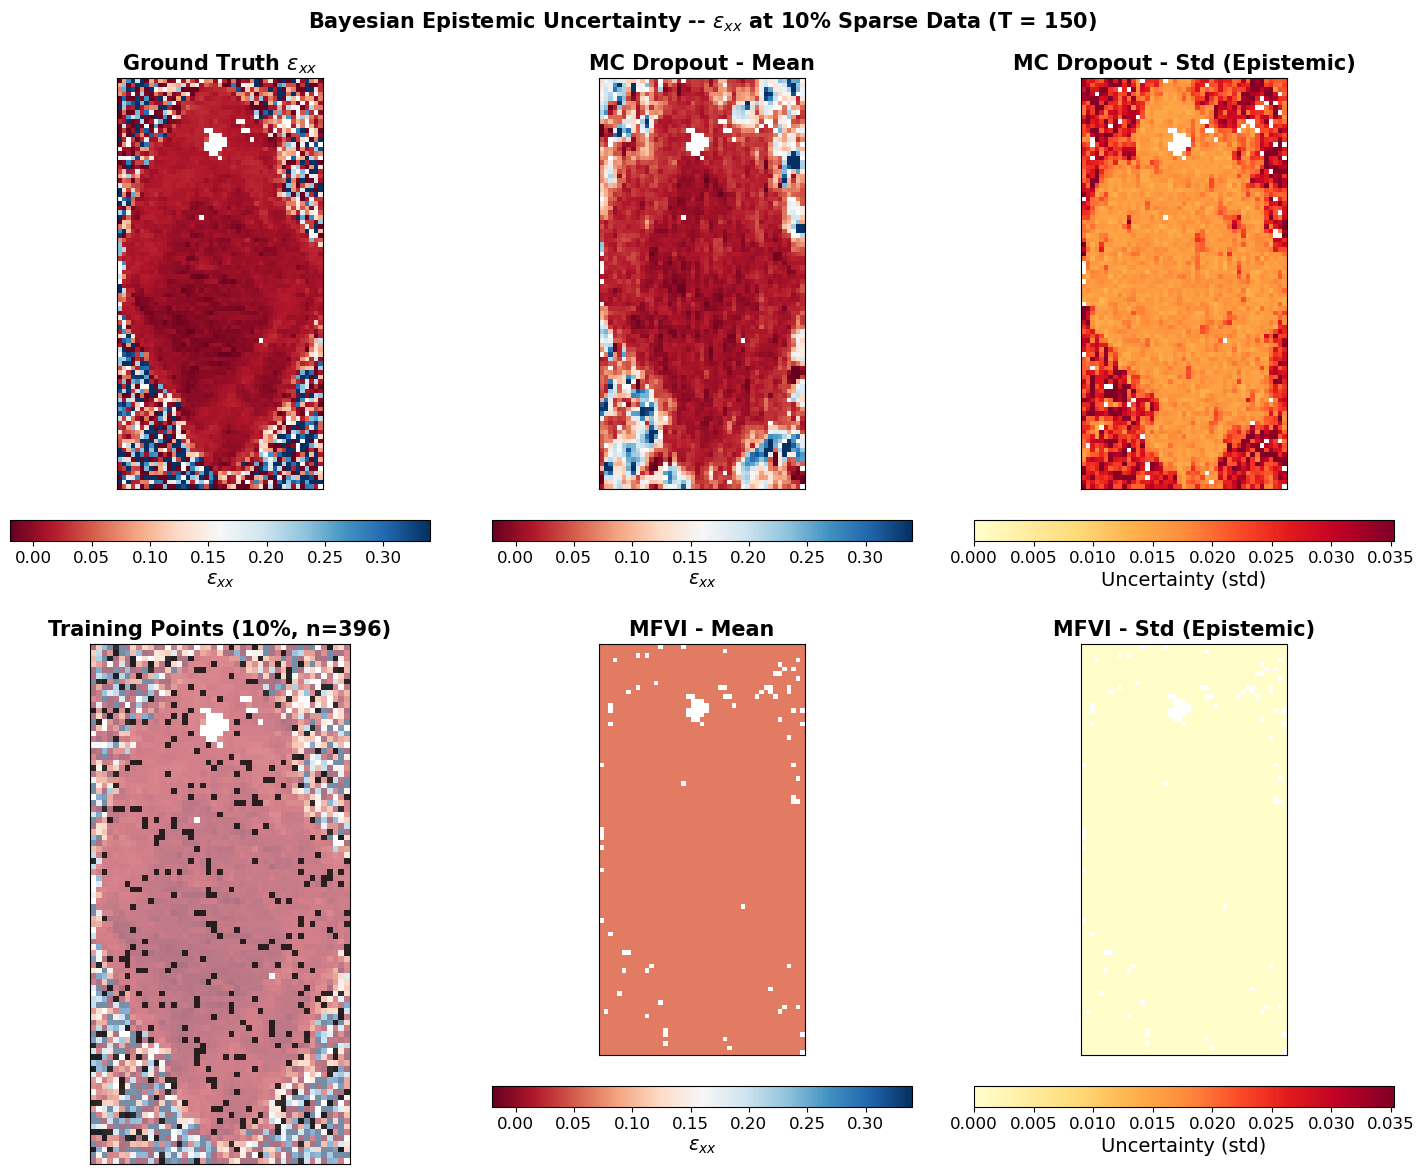

Saved: /Users/robertodosreis/Documents/codes/pinns-4dstem/outputs/sota_adaptive-2-LiFePO4/fig6_uq_exx.png


In [26]:
# ============================================================================
# SECTION 10: Bayesian Epistemic Uncertainty (MC Dropout + MFVI)
# ============================================================================

# --- MC Dropout SIREN ---
class StrainPINN_MCDropout(nn.Module):
    def __init__(self, hidden_dim=128, num_layers=6, omega_0=1.0, drop_p=0.05):  # [FIX] was 0.1
        super().__init__()
        self.drop = nn.Dropout(p=drop_p)
        self.first = SirenLayer(2, hidden_dim, is_first=True, omega_0=omega_0)
        self.hidden_layers = nn.ModuleList([
            SirenLayer(hidden_dim, hidden_dim, is_first=False, omega_0=omega_0)
            for _ in range(num_layers - 2)
        ])
        self.skip_proj = nn.Linear(hidden_dim, hidden_dim)
        self.final = nn.Linear(hidden_dim, 4)
        with torch.no_grad():
            self.final.weight.uniform_(-np.sqrt(6 / hidden_dim), np.sqrt(6 / hidden_dim))

    def forward(self, x):
        x_h = self.first(x)                 # [FIX] no dropout on the first sine layer
        for i, layer in enumerate(self.hidden_layers):
            if i % 2 == 0 and i > 0:
                x_h = layer(x_h) + self.skip_proj(x_h)
            else:
                x_h = layer(x_h)
            x_h = self.drop(x_h)
        return self.final(x_h)

    def predict_uncertainty(self, x, T=50):
        self.train()  # keep dropout active
        with torch.no_grad():
            preds = torch.stack([self(x) for _ in range(T)], dim=0)
        return preds.mean(0), preds.std(0)


# --- Mean-Field Variational Inference SIREN ---
class BayesLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_std=0.1):
        super().__init__()
        self.w_mu  = nn.Parameter(torch.zeros(out_features, in_features))
        self.w_rho = nn.Parameter(torch.full((out_features, in_features), -9.0))  # [FIX] was -5: noise ~ weight scale
        self.b_mu  = nn.Parameter(torch.zeros(out_features))
        self.b_rho = nn.Parameter(torch.full((out_features,), -9.0))               # [FIX] was -5
        self.prior_var = prior_std ** 2
        nn.init.kaiming_uniform_(self.w_mu, a=np.sqrt(5))

    @property
    def w_sig(self): return torch.log1p(torch.exp(self.w_rho))
    @property
    def b_sig(self): return torch.log1p(torch.exp(self.b_rho))

    def forward(self, x):
        if self.training:
            w = self.w_mu + self.w_sig * torch.randn_like(self.w_mu)
            b = self.b_mu + self.b_sig * torch.randn_like(self.b_mu)
        else:
            w, b = self.w_mu, self.b_mu
        return nn.functional.linear(x, w, b)

    def kl(self):
        pv = self.prior_var
        kl_w = 0.5 * ((self.w_sig**2 + self.w_mu**2) / pv - 1.0
                      - torch.log(self.w_sig**2 / pv))
        kl_b = 0.5 * ((self.b_sig**2 + self.b_mu**2) / pv - 1.0
                      - torch.log(self.b_sig**2 / pv))
        return kl_w.sum() + kl_b.sum()


class SirenBayes(nn.Module):
    def __init__(self, in_f, out_f, is_first=False, omega_0=1.0):
        super().__init__()
        self.omega_0 = omega_0
        self.linear = BayesLinear(in_f, out_f,
                                  prior_std=(1.0 / in_f if is_first else float(np.sqrt(6 / in_f)) / omega_0))  # [FIX] prior matched to SIREN weight scale
        with torch.no_grad():
            if is_first:
                self.linear.w_mu.uniform_(-1 / in_f, 1 / in_f)
            else:
                bound = np.sqrt(6 / in_f) / omega_0
                self.linear.w_mu.uniform_(-bound, bound)
    def forward(self, x): return torch.sin(self.omega_0 * self.linear(x))
    def kl(self):         return self.linear.kl()


class StrainPINN_MFVI(nn.Module):
    def __init__(self, hidden_dim=128, num_layers=6, omega_0=1.0):
        super().__init__()
        self._omega_0 = omega_0
        self.first = SirenBayes(2, hidden_dim, is_first=True, omega_0=omega_0)
        self.hidden_layers = nn.ModuleList([
            SirenBayes(hidden_dim, hidden_dim, omega_0=omega_0)
            for _ in range(num_layers - 2)
        ])
        self.skip_proj = BayesLinear(hidden_dim, hidden_dim,
                                     prior_std=float(np.sqrt(6 / hidden_dim)) / omega_0)  # [FIX] matched prior
        self.final     = BayesLinear(hidden_dim, 4,
                                     prior_std=float(np.sqrt(6 / hidden_dim)))            # [FIX] matched prior

    def forward(self, x):
        x_h = self.first(x)
        for i, layer in enumerate(self.hidden_layers):
            if i % 2 == 0 and i > 0:
                x_h = layer(x_h) + torch.sin(self._omega_0 * self.skip_proj(x_h))
            else:
                x_h = layer(x_h)
        return self.final(x_h)

    def kl_total(self):
        kl = self.first.kl() + self.skip_proj.kl() + self.final.kl()
        for l in self.hidden_layers: kl += l.kl()
        return kl

    def predict_uncertainty(self, x, T=50):
        self.train()
        with torch.no_grad():
            preds = torch.stack([self(x) for _ in range(T)], dim=0)
        return preds.mean(0), preds.std(0)


# --- Shared Bayesian Training Loop ---
def train_bayes_model(model, sparse_mask, n_epochs=3000, lr=1e-3, kl_scale=1e-6):
    ema_state = {}                      # [FIX] running scale of the physics residuals
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=500, gamma=0.95)
    for epoch in trange(n_epochs, desc=model.__class__.__name__, leave=False):
        model.train()
        opt.zero_grad()
        lam = 1.0 - np.exp(-epoch / config["ramp_tau"])   # [FIX] ramp physics like the deterministic loop
        total, ld, lp = pinn_loss_with_physics(
            model, x_flat, y_flat,
            e_xx_scaled, e_yy_scaled, e_xy_scaled, theta_scaled,
            sparse_mask, H, W, device, config, ema_state, lam
        )
        dev = next(model.parameters()).device
        kl = model.kl_total() * kl_scale if hasattr(model, 'kl_total') else torch.zeros(1, device=dev).squeeze()
        loss = total + kl
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()


# --- Train at 10% sampling ---
TARGET_FRAC = 0.10
T_PASSES    = 150
sparse_10   = sparse_masks[TARGET_FRAC]

print('Training MC-Dropout PINN at 10% sampling ...')
mcd_model = StrainPINN_MCDropout(
    hidden_dim=config['hidden_dim'], num_layers=config['num_layers'],
    omega_0=config['omega_0']           # [FIX] was default 1.0
).to(device)
train_bayes_model(mcd_model, sparse_10, n_epochs=3000)

print('Training MFVI PINN at 10% sampling ...')
mfvi_model = StrainPINN_MFVI(
    hidden_dim=config['hidden_dim'], num_layers=config['num_layers'],
    omega_0=config['omega_0']           # [FIX] was default 1.0
).to(device)
train_bayes_model(mfvi_model, sparse_10, n_epochs=3000, kl_scale=1e-6)

print('Running stochastic inference ...')
inputs_all = torch.stack([x_flat, y_flat], dim=1)
mcd_mean_s,  mcd_std_s  = mcd_model.predict_uncertainty(inputs_all,  T=T_PASSES)
mfvi_mean_s, mfvi_std_s = mfvi_model.predict_uncertainty(inputs_all, T=T_PASSES)

def _to_map(t_scaled, name, H, W, mask_np):
    arr = unscale(t_scaled[:, 0], name).cpu().numpy().reshape(H, W)
    arr[~(mask_np > 0.5)] = np.nan
    return arr

def _std_map(t_std, H, W, mask_np):
    arr = (t_std[:, 0] * scalers['e_xx']['std']).cpu().numpy().reshape(H, W)  # [FIX] std in strain units, same as the mean maps
    arr[~(mask_np > 0.5)] = np.nan
    return arr

mcd_mean  = _to_map(mcd_mean_s,  'e_xx', H, W, mask)
mfvi_mean = _to_map(mfvi_mean_s, 'e_xx', H, W, mask)
mcd_std   = _std_map(mcd_std_s,  H, W, mask)
mfvi_std  = _std_map(mfvi_std_s, H, W, mask)
print('Uncertainty maps computed')

# --- Figure 6 ---
# --- Figure 6  (colorbar bottom, large fonts) ---
FS6     = 14
FS6_T   = 15
FS6_SUP = 15

valid_m = mask > 0.5
gt_plot = np.where(valid_m, e_xx, np.nan)
all_means = np.concatenate([mcd_mean[valid_m], mfvi_mean[valid_m], gt_plot[valid_m]])
vmin_m = float(np.nanpercentile(all_means, 2))
vmax_m = float(np.nanpercentile(all_means, 98))
all_stds = np.concatenate([mcd_std[valid_m], mfvi_std[valid_m]])
vmax_s   = float(np.nanpercentile(all_stds, 98))

def _cb6(im, ax, label):
    cb = plt.colorbar(im, ax=ax, location='bottom', pad=0.06, shrink=0.85)
    cb.set_label(label, fontsize=FS6)
    cb.ax.tick_params(labelsize=FS6 - 2)
    return cb

fig, axes = plt.subplots(2, 3, figsize=(15, 12))

# Row 0: GT | MCD mean | MCD std
im = axes[0,0].imshow(gt_plot,   cmap='RdBu',   origin='lower', vmin=vmin_m, vmax=vmax_m)
axes[0,0].set_title('Ground Truth $\\varepsilon_{xx}$', fontsize=FS6_T, fontweight='bold')
_cb6(im, axes[0,0], '$\\varepsilon_{xx}$')

im = axes[0,1].imshow(mcd_mean,  cmap='RdBu',   origin='lower', vmin=vmin_m, vmax=vmax_m)
axes[0,1].set_title('MC Dropout - Mean', fontsize=FS6_T, fontweight='bold')
_cb6(im, axes[0,1], '$\\varepsilon_{xx}$')

im = axes[0,2].imshow(mcd_std,   cmap='YlOrRd', origin='lower', vmin=0, vmax=vmax_s)
axes[0,2].set_title('MC Dropout - Std (Epistemic)', fontsize=FS6_T, fontweight='bold')
_cb6(im, axes[0,2], 'Uncertainty (std)')

# Row 1: sampling overlay | MFVI mean | MFVI std
sp_np = sparse_masks[TARGET_FRAC].cpu().numpy().reshape(H, W)
# Show GT underneath; overlay training pixels as 1-px black dots (avoids scatter clutter)
axes[1,0].imshow(gt_plot, cmap='RdBu', origin='lower', vmin=vmin_m, vmax=vmax_m, alpha=0.55)
rgba_pts = np.zeros((H, W, 4), dtype=np.float32)
rgba_pts[sp_np > 0.5] = [0.05, 0.05, 0.05, 0.85]
axes[1,0].imshow(rgba_pts, origin='lower', interpolation='nearest')
axes[1,0].set_title(f'Training Points (10%, n={int(sp_np.sum()):,})', fontsize=FS6_T, fontweight='bold')

im = axes[1,1].imshow(mfvi_mean, cmap='RdBu',   origin='lower', vmin=vmin_m, vmax=vmax_m)
axes[1,1].set_title('MFVI - Mean', fontsize=FS6_T, fontweight='bold')
_cb6(im, axes[1,1], '$\\varepsilon_{xx}$')

im = axes[1,2].imshow(mfvi_std,  cmap='YlOrRd', origin='lower', vmin=0, vmax=vmax_s)
axes[1,2].set_title('MFVI - Std (Epistemic)', fontsize=FS6_T, fontweight='bold')
_cb6(im, axes[1,2], 'Uncertainty (std)')

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(
    f'Bayesian Epistemic Uncertainty -- $\\varepsilon_{{xx}}$ at 10% Sparse Data (T = {T_PASSES})',
    fontsize=FS6_SUP, fontweight='bold'
)
plt.tight_layout()
fig.savefig(out_dir / 'fig6_uq_exx.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out_dir / "fig6_uq_exx.png"}')


## CONCLUSIONS & FUTURE DIRECTIONS

**[PLACEHOLDER — this notebook has not been executed on the LiFePO4/FePO4 dataset yet.
Sections 1-4 below still read approximately the same as the PbGeSnSe1.5Te1.5 companion notebook;
replace every numeric claim with the real results from a full run before using this in the SI.]**

### What this notebook shows

1. **Data efficiency.** A SIREN coordinate network recovers the dominant strain structure of the
   LiFePO4/FePO4 platelet from a small fraction of probe positions: R²(e_xx) ≈ **[TBD]** at
   1 / 5 / 10 / 25 / 50 / 75% sampling. The dataset is much smaller than the main example
   (90×45 = 4,050 points vs. 72,000), so the same sampling fractions correspond to far fewer
   absolute probe positions (e.g. ≈40 at 1%) — expect noisier low-sampling behaviour.
2. **Against classical baselines.** **[TBD]** MAE(e_xx) reduction vs. compressed sensing (wavelet
   ISTA) and Gaussian-process regression at 10% sampling (Section 8d).
3. **When physics helps — and when it does not.** Against an identical data-only SIREN (equal
   data, capacity, and schedule; Section 8c), **[TBD]** whether the elasticity prior helps or
   biases the fit at each sampling fraction. The physically expected mechanism differs from the
   main example: LiFePO4 ⇌ FePO4 delithiation is a two-phase transformation with strain
   concentrated at the moving phase boundary (coherency strain between the Li-rich and Li-poor
   phases), not a static domain microstructure — see Deng et al. 2022 for the chemo-mechanical
   picture. Homogeneous isotropic equilibrium is likewise only an approximate prior here, for a
   different physical reason (an unmodelled phase-boundary eigenstrain rather than a static
   ferroelastic one).
4. **Uncertainty quantification.** MC-dropout and mean-field-VI variants (Section 10) yield
   epistemic uncertainty maps at 10% sampling that highlight under-sampled and high-gradient
   regions — useful as an acquisition-steering signal.

### Practical implications for acquisition

If the quantity of interest is strain-band morphology rather than pixel-level speckle, **10–25% of
probe positions suffice**, i.e. a ≈4–10× reduction in electron dose, scan time, and data volume.
This is directly relevant to beam-sensitive materials and in-situ experiments; the uncertainty maps
suggest a route to adaptive (steered) acquisition.

### Limitations and caveats

- Physics residuals are formed on per-component standardised fields; unequal component stds slightly
  distort ν in the elastic operator. A cleaner formulation would build residuals on physical-unit
  strains.
- Normalisation statistics (mean/std) are computed from Bragg-fit-valid (mask == 1) points only —
  still a mild information leak relative to a strict prospective sparse-acquisition scenario, since
  those statistics are computed over the full valid region rather than only the sparsely sampled points.
- Unlike the main worked example, θ here is an **independently measured** rotation channel, not
  derived via arctan2 from (e_xx, e_yy, e_xy) — its reconstruction scores are directly comparable
  to the strain channels', with no derived-quantity caveat.
- `E`, `nu`, and `px_um` in the configuration cell are placeholders (see the SPECIMEN block) and
  must be verified against the actual Hughes-dataset values before publication.
- The valid-pixel mask marks only Bragg-disk-fit failures (94/4,050 points here); the noisy region
  outside the physical platelet is still `mask == 1` and is not separately excluded from sampling.
- The GP baseline is capped at 1,500 training points for tractability, so comparisons at ≥25%
  sampling understate GP performance (less of a constraint here given the smaller grid).
- One dataset and one mask realisation per fraction; repeated random masks would give error bars.

### Future directions

1. **Phase-boundary/eigenstrain-aware physics**: jointly infer a coherency-eigenstrain field
   localised to the moving phase boundary so the equilibrium residual is exact through the
   transformation front — this could extend the benefit of the prior beyond the 1% regime.
2. **Adaptive loss balancing** (GradNorm / NTK-based) in place of the fixed ramp + EMA
   normalisation used here.
3. **Aspect-corrected coordinates** (x ∈ [0, W/H]): a small verified gain (+0.005–0.01 R²) by making
   frequencies isotropic in pixel space.
4. **Noise-aware evaluation**: report R²/SSIM against a lightly denoised reference (e.g. median-
   filtered maps) alongside raw ground truth.
5. **Extensions**: multi-modal fusion (strain + DPC + vDFI with coupled physics), inverse problems
   (inferring E, ν or composition from strain), and steered acquisition driven by the UQ maps.

### References

- Hughes, L. A., et al. "Correlative analysis of structure and chemistry of LiₓFePO4 platelets
  using 4D-STEM and X-ray ptychography." *Materials Today* 52 (2022): 102–111.
- Deng, Haitao D., et al. "Correlative image learning of chemo-mechanics in phase-transforming
  solids." *Nature Materials* 21.5 (2022): 547–554.
- [SIREN: Implicit Neural Representations with Periodic Activation Functions](https://arxiv.org/abs/2006.09661)
- [Curriculum-Enhanced Adaptive Sampling for PINNs](https://www.mdpi.com/2227-7390/13/24/3996)
- [R-PINN: Recovery-type A-Posteriori Enhanced PINN](https://arxiv.org/html/2506.10243)
- [Failure-Informed Adaptive Sampling](https://epubs.siam.org/doi/10.1137/22M1527763)
